In [160]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Trends

In [161]:
trend_plots_dir = Path("../results/trend_plots/main_plots")
trends_dir = Path("../results/trends/main")

In [162]:
health_df = pd.read_csv('../DATA/IHME.csv')
print("\nHealth Outcomes:")
cols = ['Deaths', 'DALYs', 'Incidence']
print(health_df[cols].describe())
for col in cols:
    print(f"\n{col}:")
    print(f"  Skewness: {health_df[col].skew():.2f}")
    print(f"  Kurtosis: {health_df[col].kurtosis():.2f}")
    print(f"  Range: {health_df[col].min():.2f} - {health_df[col].max():.2f}")
    print(f"  IQR: {health_df[col].quantile(0.75) - health_df[col].quantile(0.25):.2f}")
    print(f"  CV (Coefficient of Variation): {(health_df[col].std()/health_df[col].mean())*100:.2f}%")

print("\n")
print("\nTop 10 countries by total DALYs")
top_countries = health_df.groupby('country')['DALYs'].sum().nlargest(10)
for i, (country, dalys) in enumerate(top_countries.items(), 1):
    print(f"{i:2d}. {country:20s}: {dalys:,.2f}")

print("\nDisease burden ranking")
disease_burden = health_df.groupby('cause')['DALYs'].sum().sort_values(ascending=False)
for i, (disease, dalys) in enumerate(disease_burden.items(), 1):
    pct = (dalys / disease_burden.sum()) * 100
    print(f"{i}. {disease}")
    print(f"   DALYs: {dalys:,.2f} ({pct:.1f}% of total)")


Health Outcomes:
            Deaths         DALYs    Incidence
count  4080.000000   4080.000000  4080.000000
mean    106.560419   2388.467229   644.709023
std     148.714803   3081.997229   562.438998
min       0.018552      3.253159    17.130736
25%       0.834521     36.037256    55.209294
50%      35.363586   1069.279298   630.126021
75%     193.054106   4098.072293   914.153681
max     786.820531  15796.154116  2749.443885

Deaths:
  Skewness: 1.95
  Kurtosis: 4.23
  Range: 0.02 - 786.82
  IQR: 192.22
  CV (Coefficient of Variation): 139.56%

DALYs:
  Skewness: 1.83
  Kurtosis: 3.62
  Range: 3.25 - 15796.15
  IQR: 4062.04
  CV (Coefficient of Variation): 129.04%

Incidence:
  Skewness: 1.02
  Kurtosis: 1.19
  Range: 17.13 - 2749.44
  IQR: 858.94
  CV (Coefficient of Variation): 87.24%



Top 10 countries by total DALYs
 1. Egypt               : 527,764.33
 2. Kazakhstan          : 481,668.01
 3. Morocco             : 470,727.79
 4. Ukraine             : 462,844.01
 5. Chad        

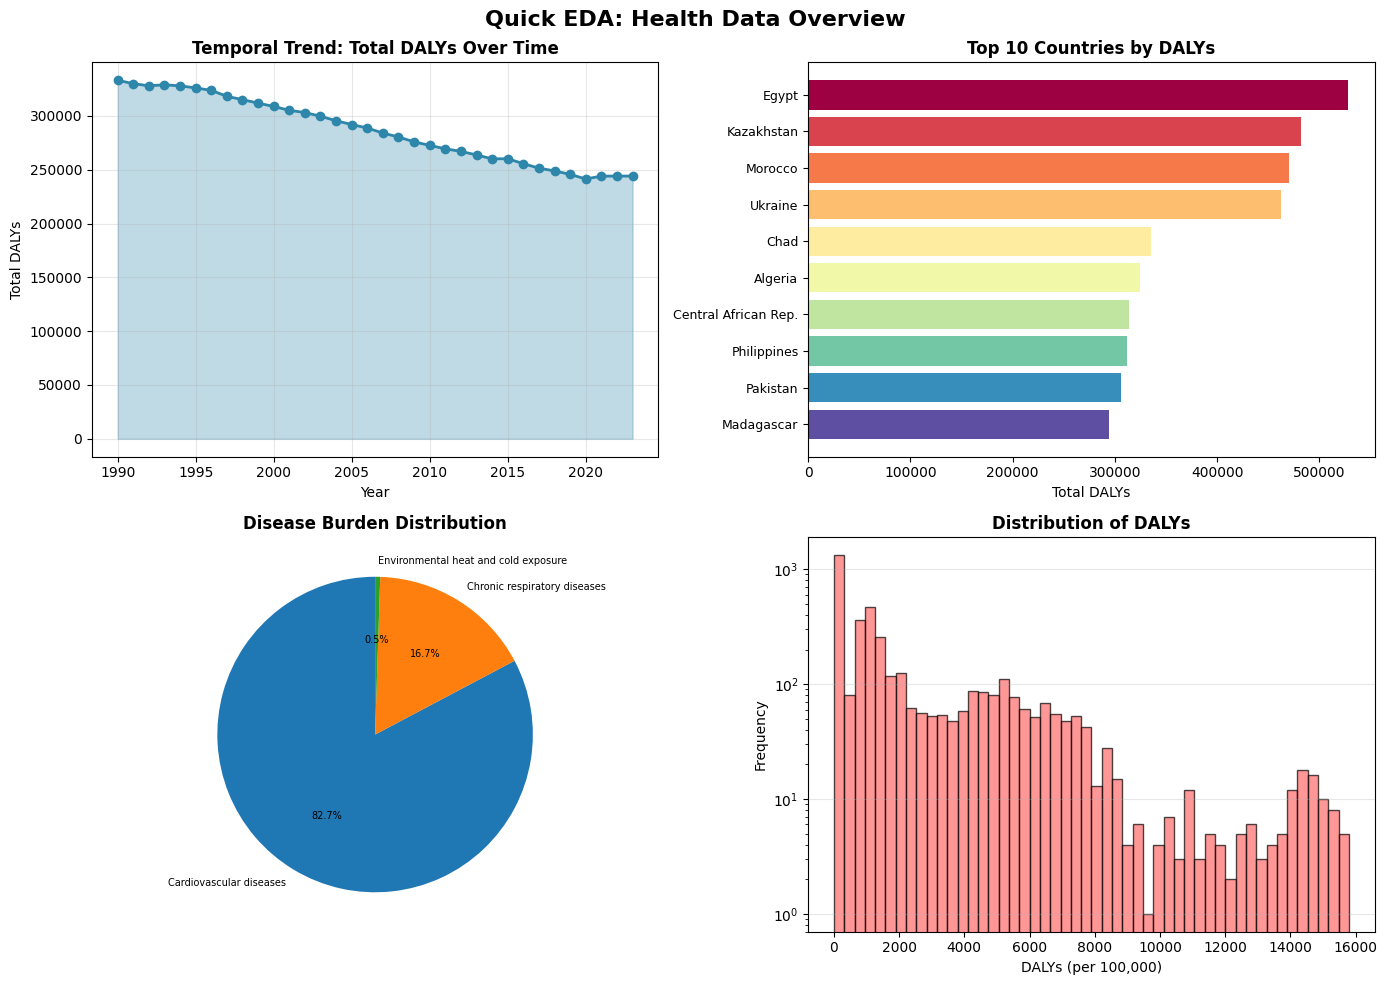

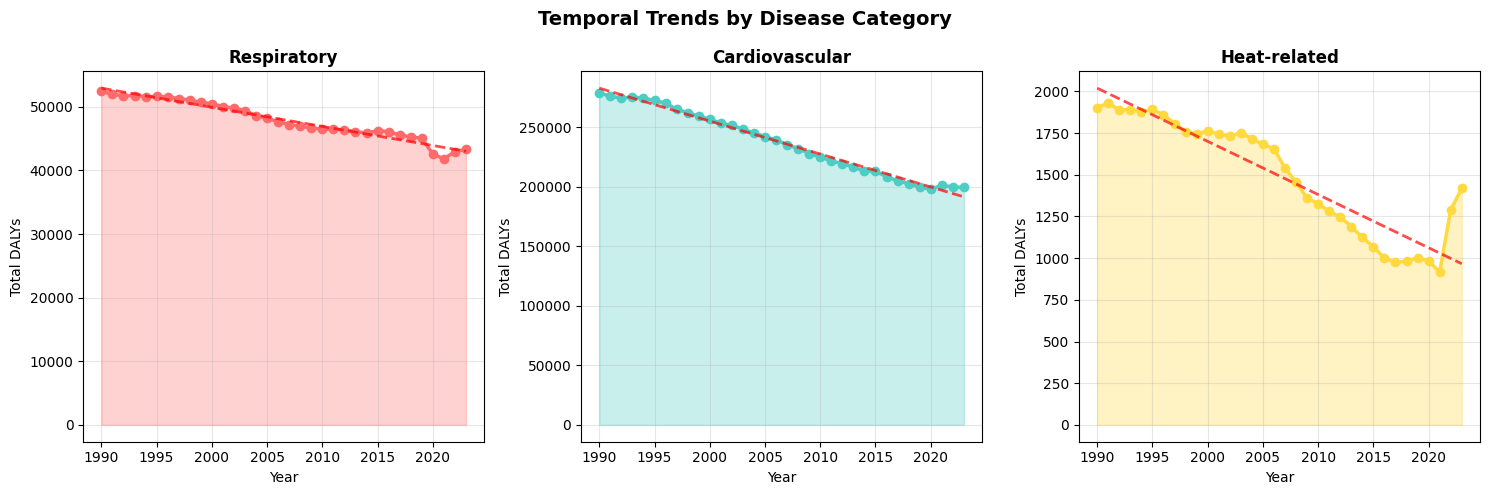

In [163]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Quick EDA: Health Data Overview', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
yearly_totals = health_df.groupby('year')['DALYs'].sum()
ax1.plot(yearly_totals.index, yearly_totals.values, 
        marker='o', linewidth=2, color='#2E86AB')
ax1.fill_between(yearly_totals.index, yearly_totals.values, alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total DALYs')
ax1.set_title('Temporal Trend: Total DALYs Over Time', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
top_10 = health_df.groupby('country')['DALYs'].sum().nlargest(10)
colors = plt.cm.Spectral(np.linspace(0, 1, 10))
ax2.barh(range(10), top_10.values, color=colors)
ax2.set_yticks(range(10))
ax2.set_yticklabels(top_10.index, fontsize=9)
ax2.set_xlabel('Total DALYs')
ax2.set_title('Top 10 Countries by DALYs', fontweight='bold')
ax2.invert_yaxis()

ax3 = axes[1, 0]
disease_totals = health_df.groupby('cause')['DALYs'].sum()
colors_disease = plt.cm.Set3(np.linspace(0, 1, len(disease_totals)))
wedges, texts, autotexts = ax3.pie(disease_totals.values, 
                                    labels=disease_totals.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 7})
ax3.set_title('Disease Burden Distribution', fontweight='bold')

ax4 = axes[1, 1]
ax4.hist(health_df['DALYs'], bins=50, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax4.set_xlabel('DALYs (per 100,000)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of DALYs', fontweight='bold')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(trend_plots_dir/'general_overview.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

disease_categories = {
    'Respiratory': ['Chronic respiratory diseases'],
    'Cardiovascular': ['Cardiovascular diseases'],
    'Heat-related': ['Environmental heat and cold exposure']
}

health_df_cat = health_df.copy()
health_df_cat['category'] = health_df_cat['cause'].apply(
    lambda x: 'Respiratory' if x in disease_categories['Respiratory'] 
    else 'Cardiovascular' if x in disease_categories['Cardiovascular']
    else 'Heat-related' if x in disease_categories['Heat-related']
    else 'Other'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Temporal Trends by Disease Category', fontsize=14, fontweight='bold')

categories = ['Respiratory', 'Cardiovascular', 'Heat-related']
colors_cat = ['#FF6B6B', '#4ECDC4', '#FFD93D']

for ax, category, color in zip(axes, categories, colors_cat):
    cat_data = health_df_cat[health_df_cat['category'] == category]
    yearly_cat = cat_data.groupby('year')['DALYs'].sum()
    
    ax.plot(yearly_cat.index, yearly_cat.values, 
            linewidth=2.5, color=color, marker='o')
    ax.fill_between(yearly_cat.index, yearly_cat.values, alpha=0.3, color=color)
    
    z = np.polyfit(yearly_cat.index, yearly_cat.values, 1)
    p = np.poly1d(z)
    ax.plot(yearly_cat.index, p(yearly_cat.index), 
            '--', color='red', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Total DALYs')
    ax.set_title(category, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(trend_plots_dir/'disease_trends.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [164]:
print("\nMortality-to-Incidence Ratio by Disease:")
disease_avg = health_df.groupby('cause')[['Deaths', 'Incidence']].mean()
disease_avg['Mortality_Rate'] = (disease_avg['Deaths'] / disease_avg['Incidence']) * 100
print(disease_avg.sort_values('Mortality_Rate', ascending=False))


Mortality-to-Incidence Ratio by Disease:
                                          Deaths    Incidence  Mortality_Rate
cause                                                                        
Cardiovascular diseases               278.287924   661.647845       42.059825
Chronic respiratory diseases           40.609124  1218.344373        3.333140
Environmental heat and cold exposure    0.784210    54.134853        1.448624


### Ukraine trends

In [165]:
health_df

,Unnamed: 0,country,year,cause,Deaths,DALYs,Incidence,income_level,income_level_mode
0,0,Algeria,1990,Cardiovascular diseases,531.784337,11253.922792,796.963385,LM,LM
1,1,Algeria,1990,Chronic respiratory diseases,36.091579,1002.651708,900.811251,LM,LM
2,2,Algeria,1990,Environmental heat and cold exposure,0.136969,10.462595,34.391902,LM,LM
3,3,Algeria,1991,Cardiovascular diseases,522.176614,11022.731268,795.362271,LM,LM
4,4,Algeria,1991,Chronic respiratory diseases,34.965694,986.116056,905.463163,LM,LM
...,...,...,...,...,...,...,...,...,...
4075,4075,United States of America,2022,Chronic respiratory diseases,35.142981,1295.016713,962.612401,H,H
4076,4076,United States of America,2022,Environmental heat and cold exposure,0.525709,27.539561,83.354391,H,H
4077,4077,United States of America,2023,Cardiovascular diseases,144.150466,3340.587933,692.773164,H,H
4078,4078,United States of America,2023,Chronic respiratory diseases,34.564570,1296.314635,999.238323,H,H


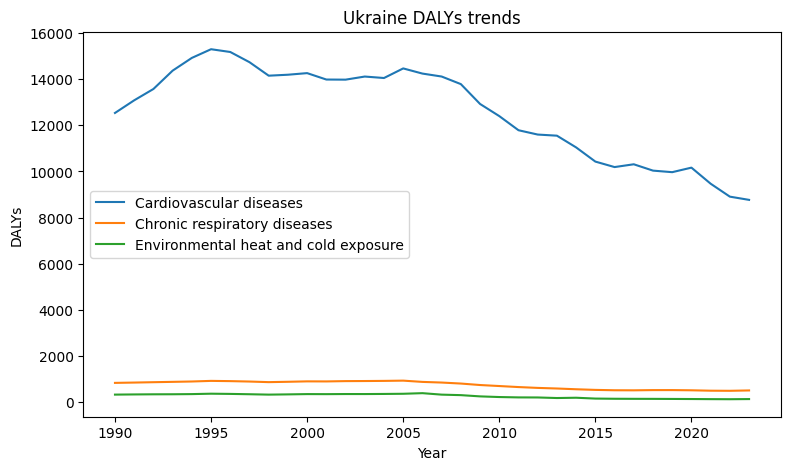

<Figure size 640x480 with 0 Axes>

In [166]:
ua = health_df[health_df["country"]=="Ukraine"]

plt.figure(figsize=(9,5))
for cat in ua["cause"].unique():
    d = ua[ua["cause"]==cat]
    plt.plot(d["year"], d["DALYs"], label=cat)

plt.legend()
plt.title("Ukraine DALYs trends")
plt.xlabel("Year")
plt.ylabel("DALYs")
plt.show()
plt.savefig(trend_plots_dir/'UKR_all_trends.png', dpi=300, bbox_inches='tight')

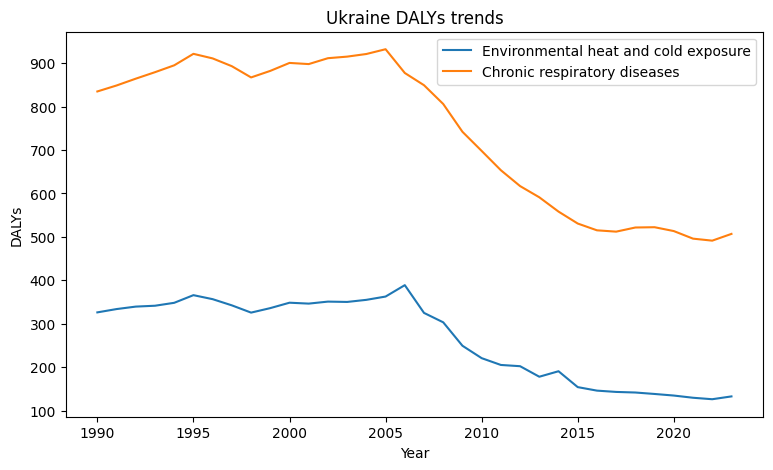

<Figure size 640x480 with 0 Axes>

In [167]:
plt.figure(figsize=(9,5))
for cat in ['Environmental heat and cold exposure', 'Chronic respiratory diseases']:
    d = ua[ua["cause"]==cat]
    plt.plot(d["year"], d["DALYs"], label=cat)

plt.legend()
plt.title("Ukraine DALYs trends")
plt.xlabel("Year")
plt.ylabel("DALYs")
plt.show()
plt.savefig(trend_plots_dir/'UKR_two_trends.png', dpi=300, bbox_inches='tight')

# Temporal trend analysis by country

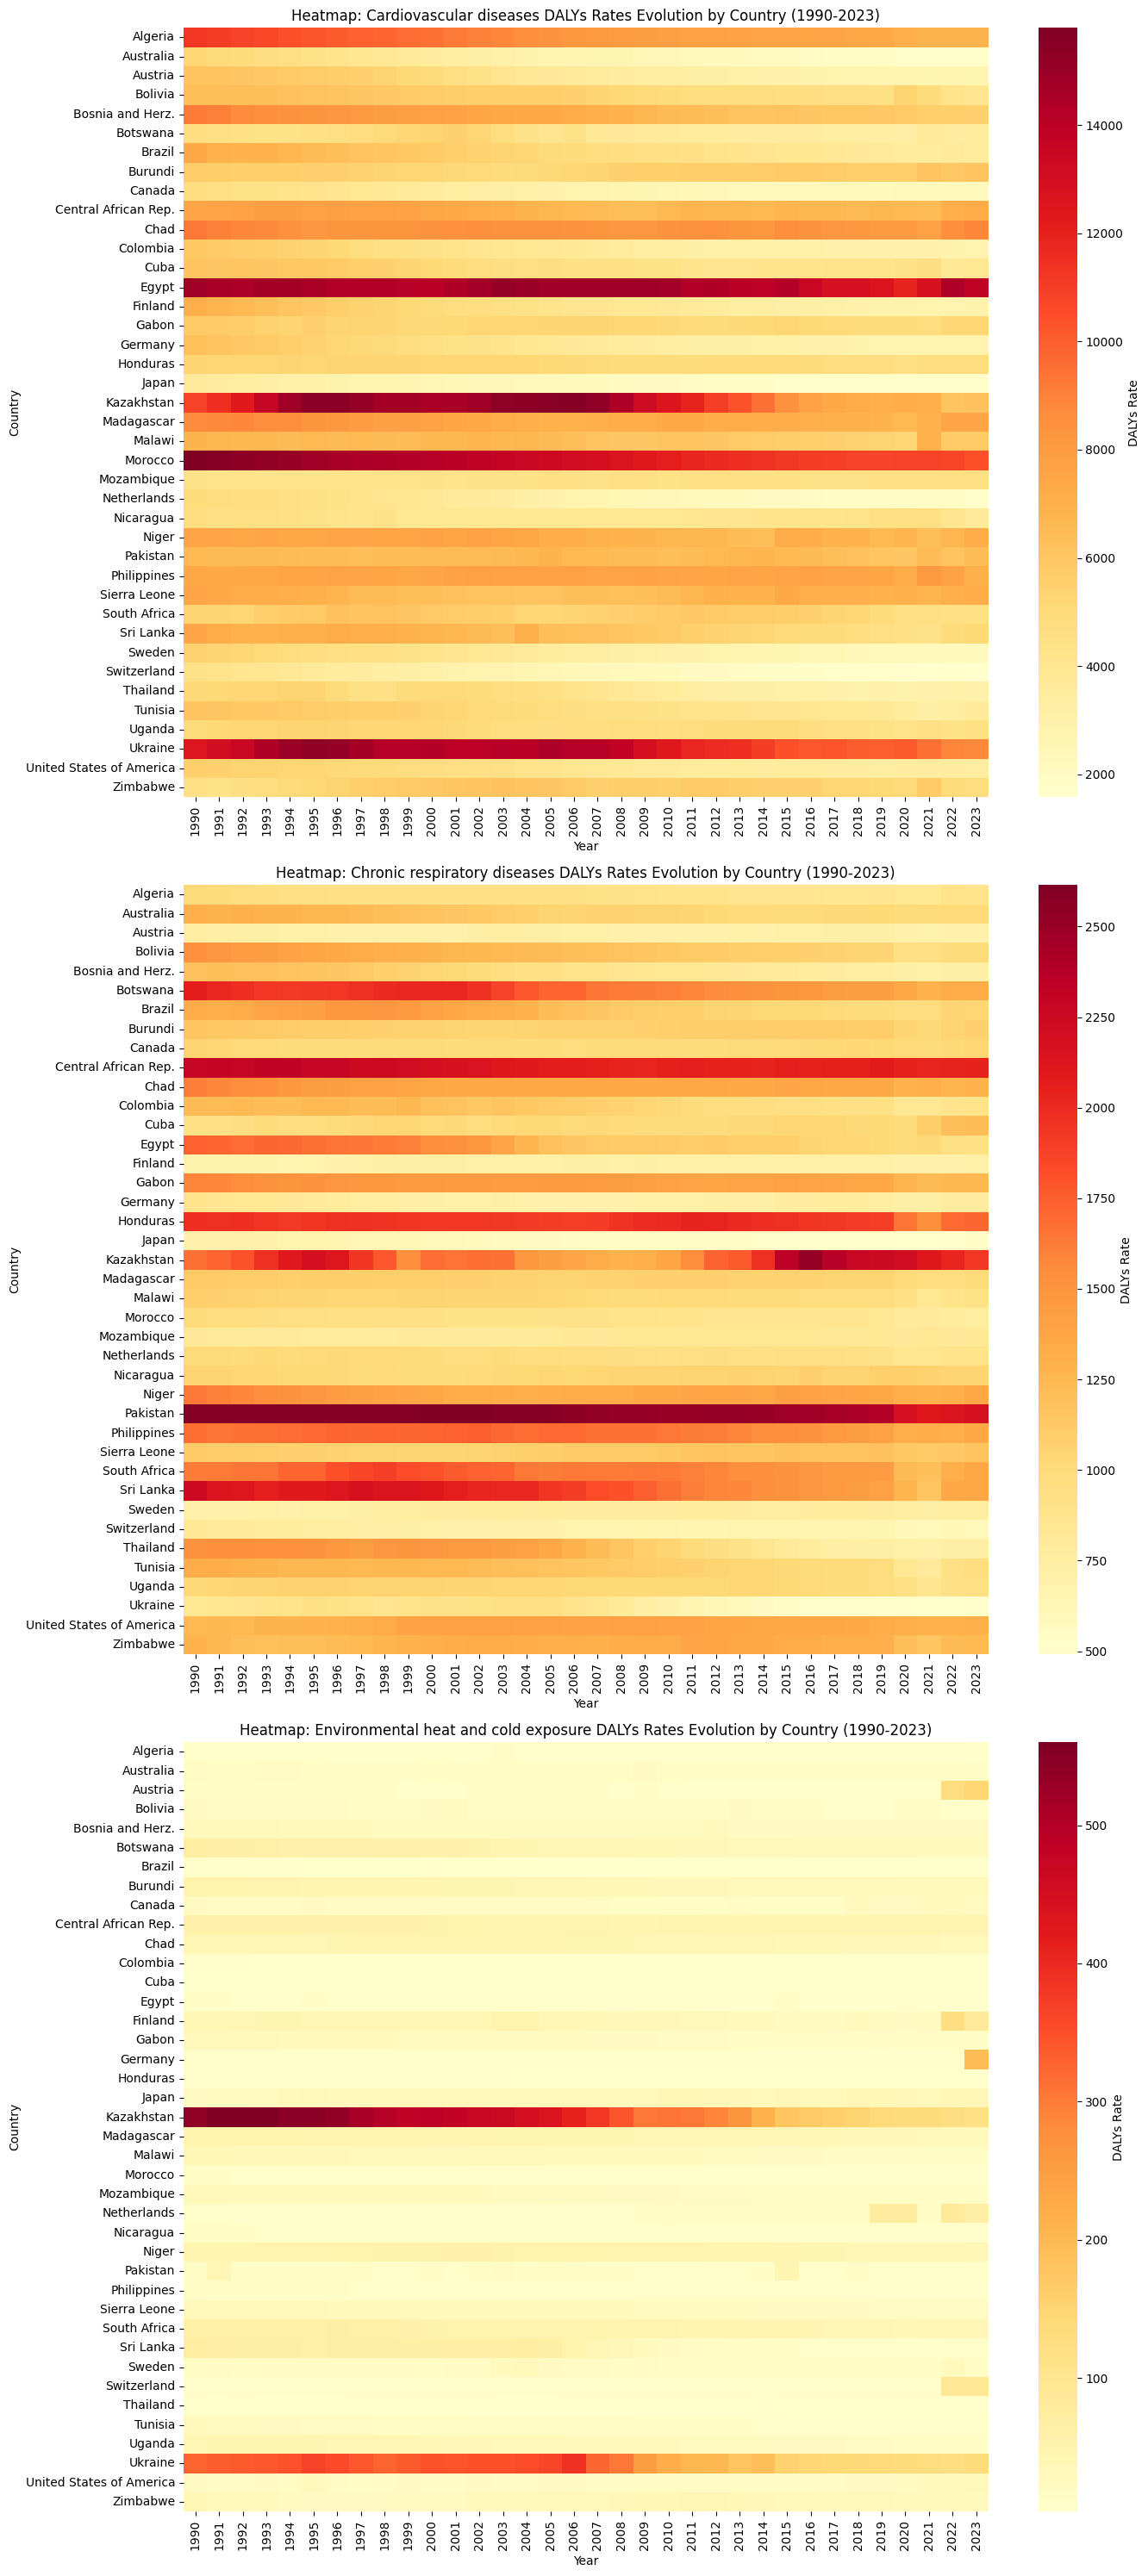

In [168]:
causes = [
    "Cardiovascular diseases",
    "Chronic respiratory diseases", 
    "Environmental heat and cold exposure"
]

fig, axes = plt.subplots(3, 1, figsize=(14, 30))

for i, cause in enumerate(causes):
    df_cause = health_df[health_df["cause"] == cause]
    pivot_heatmap = df_cause.pivot(index='country', columns='year', values='DALYs')
    sns.heatmap(pivot_heatmap, cmap='YlOrRd', cbar_kws={'label': 'DALYs Rate'}, ax=axes[i])
    axes[i].set_title(f'Heatmap: {cause} DALYs Rates Evolution by Country (1990-2023)')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Country')

plt.tight_layout()
plt.savefig(trend_plots_dir/'disease_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()


## Global trends

In [169]:
def compute_trend(df, value_col="DALYs"):
    
    yearly = df.groupby("year")[value_col].mean()
    
    if len(yearly) < 2:
        return None
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        yearly.index.values,
        yearly.values
    )
    
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r_value**2,
        "p_value": p_value,
        "std_err": std_err
    }
global_results = []

for cause in health_df["cause"].unique():
    
    df_cause = health_df[health_df["cause"] == cause]
    result = compute_trend(df_cause)
    
    if result is not None:
        result.update({"cause": cause})
        global_results.append(result)

global_trend_df = pd.DataFrame(global_results)
def add_significance(df):
    df["significant"] = df["p_value"] < 0.05
    df["trend_direction"] = np.where(df["slope"] > 0, "increasing", "decreasing")
    return df
global_trend_df = add_significance(global_trend_df)
global_trend_df.to_csv(trends_dir/'global_slopes.csv')
global_trend_df

,slope,intercept,r2,p_value,std_err,cause,significant,trend_direction
0,-69.147766,144673.902338,0.988439,1.432770e-32,1.321974,Cardiovascular diseases,True,decreasing
1,-7.509490,16266.957086,0.956880,2.041291e-23,0.281805,Chronic respiratory diseases,True,decreasing
2,-0.797858,1638.230458,0.846422,1.449235e-14,0.060079,Environmental heat and cold exposure,True,decreasing


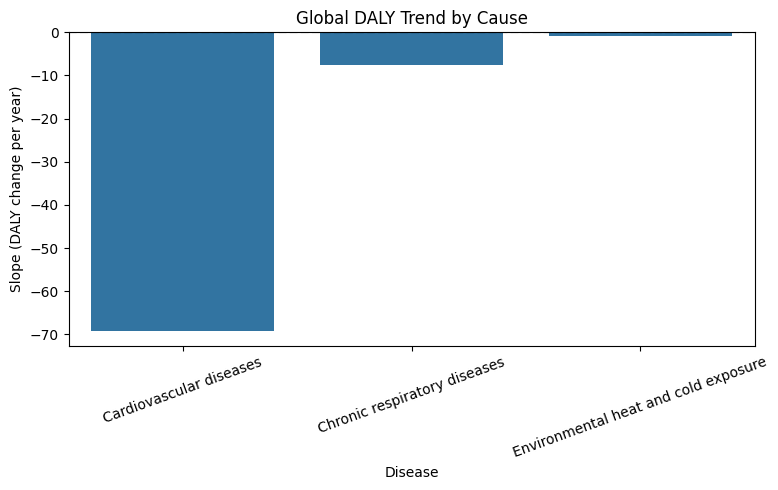

In [170]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=global_trend_df,
    x="cause",
    y="slope"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Global DALY Trend by Cause")
plt.ylabel("Slope (DALY change per year)")
plt.xlabel("Disease")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig(trend_plots_dir/'global_slopes.png', dpi=300, bbox_inches='tight')
plt.show()

## Trends by country

In [171]:
country_results = []

for cause in health_df["cause"].unique():
    
    df_cause = health_df[health_df["cause"] == cause]
    
    for country in df_cause["country"].unique():
        
        temp = df_cause[df_cause["country"] == country]
        result = compute_trend(temp)
        
        if result is not None:
            result.update({
                "cause": cause,
                "country": country
            })
            country_results.append(result)

country_trend_df = pd.DataFrame(country_results)
country_trend_df.to_csv(trends_dir/'country_slopes.csv')
country_trend_df

,slope,intercept,r2,p_value,std_err,cause,country
0,-131.405477,272289.473014,0.955093,3.911699e-23,5.037004,Cardiovascular diseases,Algeria
1,-63.434171,132644.429493,0.907046,4.551133e-18,3.589771,Cardiovascular diseases,Bolivia
2,14.091155,-22754.424669,0.234830,3.680201e-03,4.496496,Cardiovascular diseases,Burundi
3,-38.324857,83948.723200,0.570341,2.447441e-07,5.880304,Cardiovascular diseases,Central African Rep.
4,-14.444056,37407.898870,0.256113,2.260984e-03,4.351630,Cardiovascular diseases,Chad
...,...,...,...,...,...,...,...
115,-0.008243,20.765582,0.024263,3.790320e-01,0.009241,Environmental heat and cold exposure,Thailand
116,1.352875,-2696.852122,0.388445,8.241306e-05,0.300079,Environmental heat and cold exposure,Netherlands
117,-0.129547,278.317222,0.121853,4.302613e-02,0.061478,Environmental heat and cold exposure,Sweden
118,0.757256,-1507.593162,0.142239,2.789354e-02,0.328731,Environmental heat and cold exposure,Switzerland


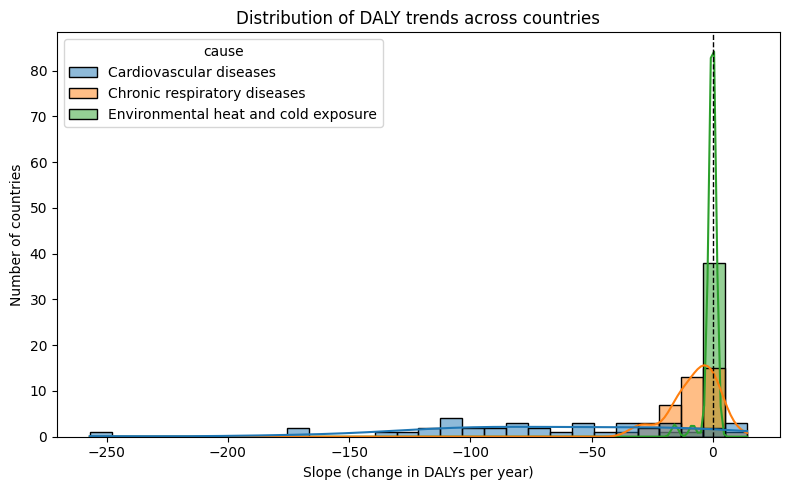

In [172]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=country_trend_df, x="slope", hue="cause", bins=30, kde=True
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of DALY trends across countries")
plt.xlabel("Slope (change in DALYs per year)")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(trend_plots_dir/'country_slopes.png', dpi=300, bbox_inches='tight')
plt.show()

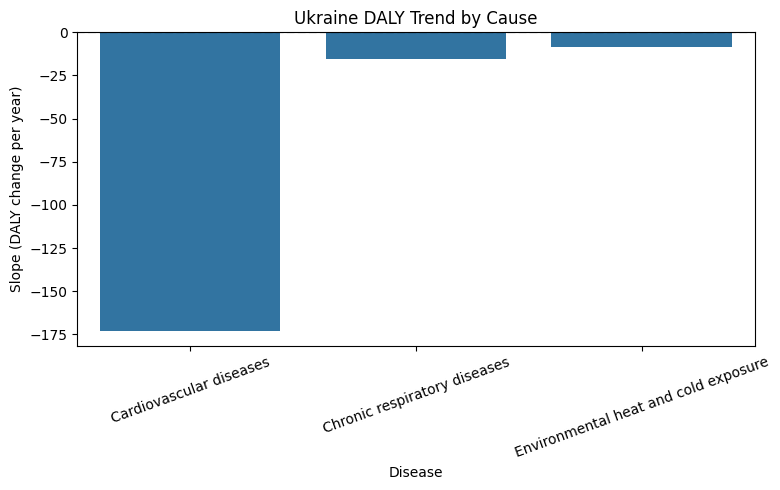

In [173]:
ua = country_trend_df[country_trend_df["country"]=="Ukraine"]
plt.figure(figsize=(8,5))
sns.barplot(
    data=ua,
    x="cause",
    y="slope"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Ukraine DALY Trend by Cause")
plt.ylabel("Slope (DALY change per year)")
plt.xlabel("Disease")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig(trend_plots_dir/'UKR_slopes.png', dpi=300, bbox_inches='tight')
plt.show()

In [174]:
trend_df = country_trend_df.copy()
trend_df["significant"] = trend_df["p_value"] < 0.05
trend_df["trend_direction"] = np.where(
    trend_df["slope"] > 0,
    "Increasing",
    "Decreasing"
)
trend_df["trend_type"] = np.where(
    trend_df["significant"],
    trend_df["trend_direction"],
    "Not significant"
)
total_per_cause = trend_df.groupby("cause").size().reset_index(name="total")
significant_per_cause = (
    trend_df[trend_df["significant"]]
    .groupby("cause")
    .size()
    .reset_index(name="significant_count")
)
merged = total_per_cause.merge(significant_per_cause, on="cause")
merged["percent_significant"] = (
    merged["significant_count"] / merged["total"] * 100
)
merged

,cause,total,significant_count,percent_significant
0,Cardiovascular diseases,40,36,90.0
1,Chronic respiratory diseases,40,35,87.5
2,Environmental heat and cold exposure,40,34,85.0


In [175]:
top_decline = (
    trend_df[trend_df["significant"] & (trend_df["slope"] < 0)]
    .sort_values("slope")
    .groupby("cause")
    .head(5)
)

top_decline

,slope,intercept,r2,p_value,std_err,cause,country,significant,trend_direction,trend_type
33,-256.985516,527617.175350,0.577296,1.874673e-07,38.873368,Cardiovascular diseases,Kazakhstan,True,Decreasing,Decreasing
19,-172.844509,359416.287540,0.737158,8.372745e-11,18.245173,Cardiovascular diseases,Ukraine,True,Decreasing,Decreasing
9,-169.729169,353505.533556,0.985535,5.175548e-31,3.634979,Cardiovascular diseases,Morocco,True,Decreasing,Decreasing
0,-131.405477,272289.473014,0.955093,3.911699e-23,5.037004,Cardiovascular diseases,Algeria,True,Decreasing,Decreasing
29,-126.371414,257925.494523,0.958960,9.242907e-24,4.621427,Cardiovascular diseases,Finland,True,Decreasing,Decreasing
75,-31.517840,64413.537931,0.923111,2.168121e-19,1.607998,Chronic respiratory diseases,Thailand,True,Decreasing,Decreasing
56,-30.859618,63722.123197,0.925563,1.289458e-19,1.547064,Chronic respiratory diseases,Sri Lanka,True,Decreasing,Decreasing
45,-27.532538,56547.709667,0.919346,4.668101e-19,1.441601,Chronic respiratory diseases,Egypt,True,Decreasing,Decreasing
64,-24.313898,50495.661796,0.927074,9.280042e-20,1.205491,Chronic respiratory diseases,Botswana,True,Decreasing,Decreasing
63,-16.319755,33678.625847,0.965043,7.077422e-25,0.549080,Chronic respiratory diseases,Bosnia and Herz.,True,Decreasing,Decreasing


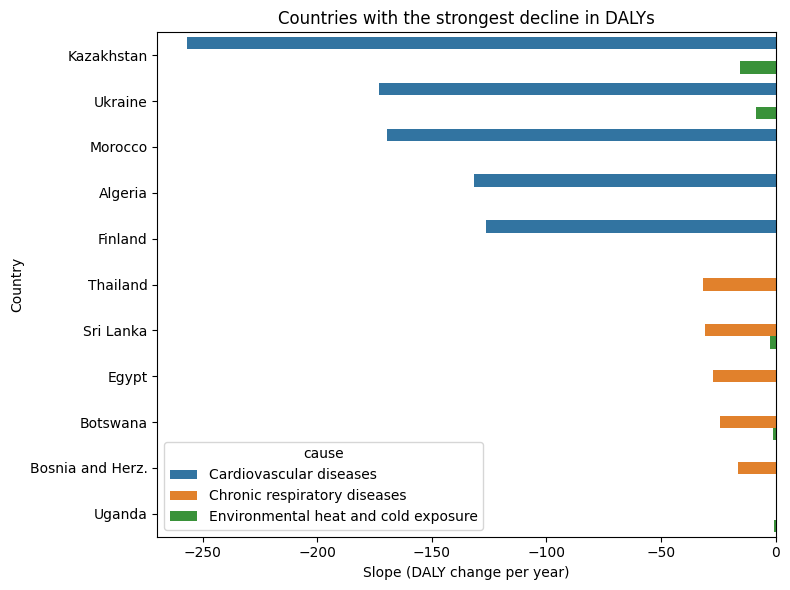

In [176]:
plt.figure(figsize=(8,6))
sns.barplot(data=top_decline, x="slope", y="country", hue="cause")
plt.title("Countries with the strongest decline in DALYs")
plt.xlabel("Slope (DALY change per year)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(trend_plots_dir/'top_decline.png', dpi=300, bbox_inches='tight')
plt.show()

In [177]:
top_increase = (
    trend_df[trend_df["significant"] & (trend_df["slope"] > 0)]
    .sort_values("slope", ascending=False)
    .groupby("cause")
    .head(5)
)

top_increase

,slope,intercept,r2,p_value,std_err,cause,country,significant,trend_direction,trend_type
2,14.091155,-22754.424669,0.234830,3.680201e-03,4.496496,Cardiovascular diseases,Burundi,True,Increasing,Increasing
10,8.824347,-13332.988123,0.638606,1.459092e-08,1.173496,Cardiovascular diseases,Mozambique,True,Increasing,Increasing
68,4.072867,-7153.969769,0.444273,1.679374e-05,0.805251,Chronic respiratory diseases,Cuba,True,Increasing,Increasing
55,3.321625,-5548.339230,0.548242,5.559013e-07,0.533019,Chronic respiratory diseases,Sierra Leone,True,Increasing,Increasing
77,1.565803,-2388.948641,0.367279,1.455535e-04,0.363304,Chronic respiratory diseases,Sweden,True,Increasing,Increasing
50,1.518709,-2231.908770,0.500266,2.912164e-06,0.268330,Chronic respiratory diseases,Mozambique,True,Increasing,Increasing
51,1.503604,-1976.487506,0.335847,3.286262e-04,0.373785,Chronic respiratory diseases,Nicaragua,True,Increasing,Increasing
116,1.352875,-2696.852122,0.388445,8.241306e-05,0.300079,Environmental heat and cold exposure,Netherlands,True,Increasing,Increasing
102,1.105813,-2199.497077,0.133246,3.377737e-02,0.498570,Environmental heat and cold exposure,Austria,True,Increasing,Increasing
118,0.757256,-1507.593162,0.142239,2.789354e-02,0.328731,Environmental heat and cold exposure,Switzerland,True,Increasing,Increasing


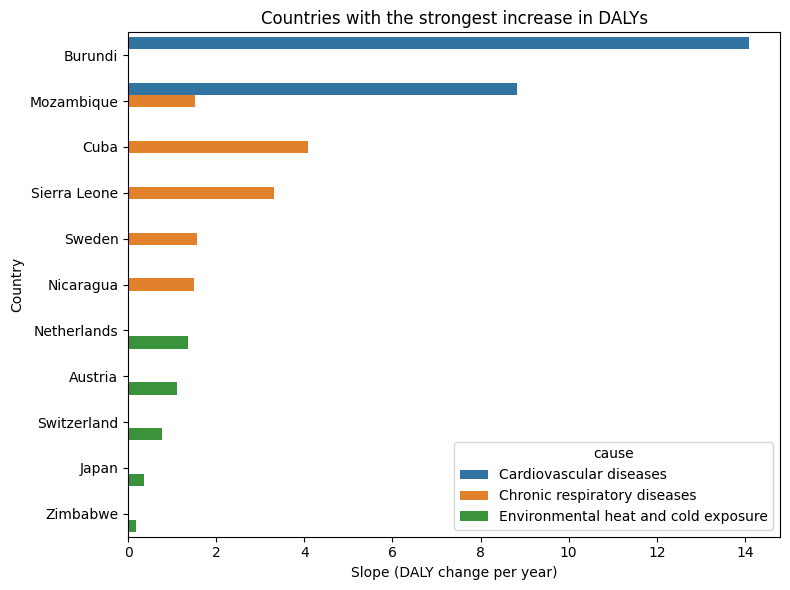

In [178]:
plt.figure(figsize=(8,6))
sns.barplot(data=top_increase, x="slope", y="country", hue="cause")
plt.title("Countries with the strongest increase in DALYs")
plt.xlabel("Slope (DALY change per year)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(trend_plots_dir/'top_increase.png', dpi=300, bbox_inches='tight')
plt.show()

## Trends by income

Since income group may vary throughout years for some countries let's take the mode income group.

In [179]:
trend_with_income = trend_df.merge(
    health_df[["country", "income_level_mode"]].drop_duplicates(),
    on="country"
)
income_summary = (
    trend_with_income
    .groupby(["income_level_mode", "cause", "trend_type"])
    .size()
    .reset_index(name="count")
)
income_summary

,income_level_mode,cause,trend_type,count
0,H,Cardiovascular diseases,Decreasing,10
1,H,Chronic respiratory diseases,Decreasing,5
2,H,Chronic respiratory diseases,Increasing,2
3,H,Chronic respiratory diseases,Not significant,3
4,H,Environmental heat and cold exposure,Decreasing,2
5,H,Environmental heat and cold exposure,Increasing,5
6,H,Environmental heat and cold exposure,Not significant,3
7,L,Cardiovascular diseases,Decreasing,7
8,L,Cardiovascular diseases,Increasing,2
9,L,Cardiovascular diseases,Not significant,2


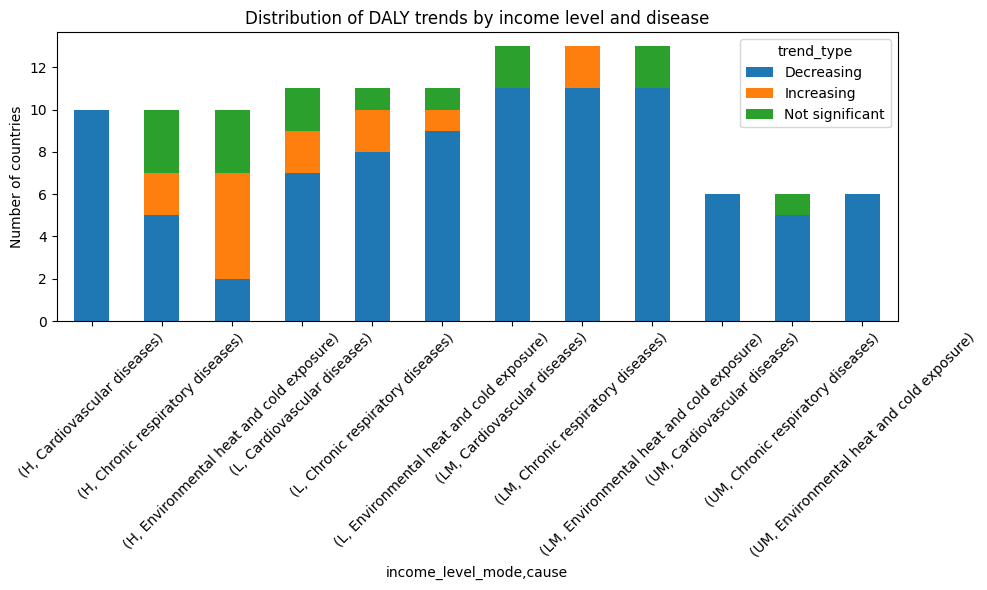

In [180]:
pivot_df = income_summary.pivot_table(
    index=["income_level_mode","cause"],
    columns="trend_type",
    values="count",
    fill_value=0
)
pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)
plt.ylabel("Number of countries")
plt.title("Distribution of DALY trends by income level and disease")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(trend_plots_dir/'distr_DALYs_by_inc.png', dpi=300, bbox_inches='tight')
plt.show()

In [181]:
income_results = []

for cause in health_df["cause"].unique():
    df_cause = health_df[health_df["cause"] == cause]
    for income in df_cause["income_level_mode"].unique():
        temp = df_cause[df_cause["income_level_mode"] == income]
        result = compute_trend(temp)
        if result is not None:
            result.update({
                "cause": cause,
                "income_level": income
            })
            income_results.append(result)
income_trend_df = pd.DataFrame(income_results)
income_trend_df.to_csv(trends_dir/'income_slopes.csv')

income_trend_df

,slope,intercept,r2,p_value,std_err,cause,income_level
0,-79.963615,167687.830122,0.985533,5.186323e-31,1.712641,Cardiovascular diseases,LM
1,-15.795897,38041.974020,0.704093,5.694090e-10,1.810223,Cardiovascular diseases,L
2,-96.887682,197826.944753,0.953169,7.660610e-23,3.796420,Cardiovascular diseases,H
3,-97.291994,201713.856699,0.866430,1.536338e-15,6.752885,Cardiovascular diseases,UM
4,-12.890414,27080.602367,0.960379,5.261386e-24,0.462845,Chronic respiratory diseases,LM
5,-3.623431,8618.095004,0.714771,3.140746e-10,0.404631,Chronic respiratory diseases,L
6,-2.491907,5862.459039,0.911921,1.917409e-18,0.136903,Chronic respiratory diseases,H
7,-11.337904,24201.136207,0.766148,1.267765e-11,1.107316,Chronic respiratory diseases,UM
8,-0.967447,1972.167140,0.862201,2.535604e-15,0.068371,Environmental heat and cold exposure,LM
9,-0.446944,930.728986,0.961964,2.734970e-24,0.015711,Environmental heat and cold exposure,L


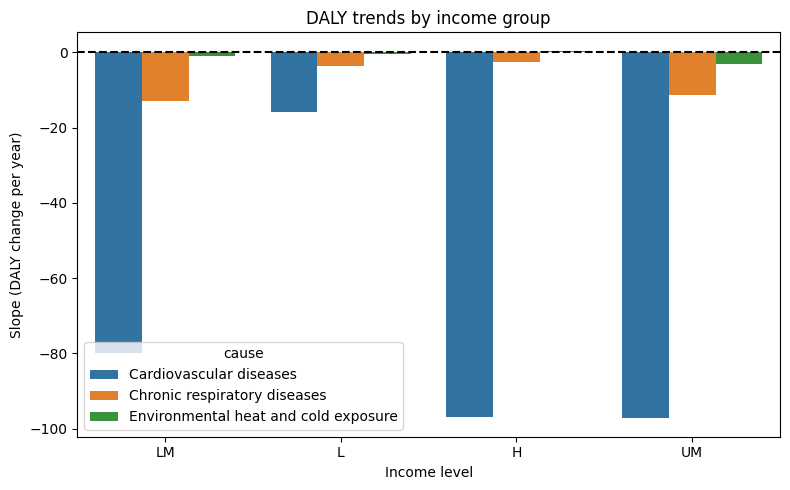

In [182]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=income_trend_df,
    x="income_level",
    y="slope",
    hue="cause"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("DALY trends by income group")
plt.ylabel("Slope (DALY change per year)")
plt.xlabel("Income level")
plt.tight_layout()
plt.savefig(trend_plots_dir/'income_group_slopes.png', dpi=300, bbox_inches='tight')
plt.show()

# Extreme years

In [183]:
pct_high = 95
pct_low  = 5
extremes_plots_dir = Path("../results/trend_plots/extremes_plots")
extremes_dir = Path("../results/trends/extremes")
weather_df = pd.read_csv('../DATA/weather.csv')
weather_df = weather_df[weather_df['year'] <= 2023]
health_df  = pd.read_csv('../DATA/IHME.csv')

In [184]:
var_directions = {
    # Heat stress
    "mean_temp":                  "BOTH",
    "max_temp":                   "HIGH",
    "anomaly_heat_days":          "HIGH",
    "heat_episodes":              "HIGH",
    "extreme_heat_episodes":      "HIGH",
    "extreme_area":               "HIGH",
    "caution_area":               "HIGH",
    "mean_caution_area":          "HIGH",
    "mean_extreme_area":          "HIGH",
    # Cold stress
    "anomaly_cold_days":          "HIGH",
    "annual_freeze_burden":       "HIGH",
    "min_temp":                   "LOW",
    "winter_mean_snow_density":   "HIGH",
    "mean_cold_area":             "HIGH",
    # Precipitation / Drought
    "heavy_rain_days":            "HIGH",
    "extreme_rain_days":          "HIGH",
    "max_year_precip":            "HIGH",
    "annual_dry_area":            "HIGH",
    "drought_episodes":           "HIGH",
    "mean_dry_area":              "HIGH",
    "evap_deficit":               "HIGH",
    # Runoff / Flood
    "runoff_days":                "HIGH",
    "max_runoff":                 "HIGH",
    # Air quality
    "pm2.5_mean":                 "HIGH",
    "ozone_mean":                 "HIGH",
    "no2_mean":                   "HIGH",
    # Wind / Pressure
    "max_monthly_wind_speed":     "HIGH",
    "mean_annual_wind_speed":     "HIGH",
    "pressure_variability":       "HIGH",
    # Moisture / Evaporation
    "mean_soil_moisture":         "LOW",
    "min_monthly_soil_moisture":  "LOW",
    "annual_total_evap":          "BOTH",
    "annual_potential_evap":      "HIGH",
    "mean_annual_rsn":            "BOTH",
    # Energy fluxes
    "mean_annual_net_solar":      "BOTH",
    "mean_annual_net_thermal":    "BOTH",
    "mean_latent_heat":           "BOTH",
    "mean_sensible_heat":         "BOTH"
}

CLIMATE_VARS = {
    "Heat stress":      ["mean_temp", "max_temp", "anomaly_heat_days", "heat_episodes",
                         "extreme_heat_episodes", "extreme_area", "caution_area",
                         "mean_caution_area", "mean_extreme_area"],
    "Cold stress":      ["anomaly_cold_days", "annual_freeze_burden", "min_temp",
                         "winter_mean_snow_density", "mean_cold_area"],
    "Air quality":      ["pm2.5_mean", "ozone_mean", "no2_mean"],
    "Precipitation":    ["hr_days", "er_days", "max_year_precip", "annual_dry_area",
                         "drought_episodes", "mean_dry_area", "evap_deficit"],
    "Runoff / Flood":   ["runoff_days", "max_runoff"],
    "Wind / Pressure":  ["max_monthly_wind_speed", "mean_annual_wind_speed",
                         "pressure_variability"],
    "Moisture / Soil":  ["mean_soil_moisture", "min_monthly_soil_moisture",
                         "annual_total_evap", "annual_potential_evap"],
    "Surface Energy Fluxes": ["mean_annual_net_solar", "mean_annual_net_thermal",
        "mean_latent_heat", "mean_sensible_heat",
    ],
}
metrics = ["Deaths", "DALYs", "Incidence"]

Let's define percentiles for each variable.

In [185]:
records = []
for country, grp in weather_df.groupby("country"):
    for var, direction in var_directions.items():
        if var not in grp.columns:
            continue
        series = grp[var].dropna()
        if len(series) < 5:
            continue
        records.append({
            "country":      country,
            "variable":     var,
            "direction":    direction,
            "thresh_high":  np.percentile(series, pct_high),
            "thresh_low":   np.percentile(series, pct_low),
            "mean":         series.mean(),
            "std":          series.std(),
            "n_obs":        len(series),
        })
if not records:
    percentiles = pd.DataFrame()
else:
    percentiles = pd.DataFrame(records).set_index(["country", "variable"])

Now detect extreme years

In [186]:
if percentiles.empty:
    extreme_df = pd.DataFrame()
else:
    rows = []
    for (country, var), thresholds in percentiles.iterrows():

        subset = (weather_df[weather_df["country"] == country][["year", var]]
                    .dropna()
                    .copy())
        if subset.empty:
            continue

        for _, row in subset.iterrows():
            val  = row[var]
            year = int(row["year"])

            is_extreme_high = (val >= thresholds["thresh_high"]) and (thresholds["direction"] in ("HIGH", "BOTH"))
            is_extreme_low  = (val <= thresholds["thresh_low"])  and (thresholds["direction"] in ("LOW",  "BOTH"))
            is_extreme = is_extreme_high or is_extreme_low

            if is_extreme_high:
                direction = "HIGH"
            elif is_extreme_low:
                direction = "LOW"
            else:
                direction = "normal"

            rows.append({
                "country":              country,
                "year":                 year,
                "variable":             var,
                "all_time_mean":        thresholds["mean"],
                "all_time_std":         thresholds["std"],
                "thresh_high":          thresholds["thresh_high"],
                "thresh_low":           thresholds["thresh_low"],
                "value":                val,
                "semantic_direction":   thresholds["direction"],
                "deviation_from_mean":  val - thresholds["mean"],
                "z_score":              (val - thresholds["mean"]) / thresholds["std"] if thresholds["std"] > 0 else 0.0,
                "direction":            direction,
                "is_extreme":           is_extreme,
            })
    extreme_df = pd.DataFrame(rows) if rows else pd.DataFrame()
extreme_df

,country,year,variable,all_time_mean,all_time_std,thresh_high,thresh_low,value,semantic_direction,deviation_from_mean,z_score,direction,is_extreme
0,Algeria,1990,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.301906e+01,BOTH,-1.134109e-01,-0.193669,normal,False
1,Algeria,1991,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.202705e+01,BOTH,-1.105420e+00,-1.887694,LOW,True
2,Algeria,1992,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.168704e+01,BOTH,-1.445428e+00,-2.468316,LOW,True
3,Algeria,1993,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.244701e+01,BOTH,-6.854540e-01,-1.170530,normal,False
4,Algeria,1994,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.261556e+01,BOTH,-5.169040e-01,-0.882702,normal,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50703,Zimbabwe,2019,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-5.679308e+06,BOTH,-5.553542e+05,-0.803938,normal,False
50704,Zimbabwe,2020,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-5.377792e+06,BOTH,-2.538372e+05,-0.367458,normal,False
50705,Zimbabwe,2021,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-4.770314e+06,BOTH,3.536403e+05,0.511934,normal,False
50706,Zimbabwe,2022,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-3.888645e+06,BOTH,1.235309e+06,1.788250,HIGH,True


In [187]:
only_extreme = extreme_df[extreme_df["is_extreme"]].copy()
def vars_for_direction(subdf, dir_label):
    return ", ".join(subdf.loc[subdf["direction"] == dir_label, "variable"].tolist())

records = []
for (country, year), grp in only_extreme.groupby(["country", "year"]):
    records.append({
        "country":            country,
        "year":               int(year),
        "n_extreme_vars":     len(grp),
        "max_z_score":        grp["z_score"].abs().max(),
        "extreme_high_vars":  vars_for_direction(grp, "HIGH"),
        "extreme_low_vars":   vars_for_direction(grp, "LOW"),
    })

agg = pd.DataFrame(records)
agg["extreme_high_count"] = agg["extreme_high_vars"].apply(
    lambda s: len(s.split(", ")) if s else 0)
agg["extreme_low_count"]  = agg["extreme_low_vars"].apply(
    lambda s: len(s.split(", ")) if s else 0)

extreme_years_table = agg.sort_values(["country", "year"]).reset_index(drop=True)
extreme_years_table.to_csv(extremes_dir / "extreme_years_table.csv", index=False)
extreme_years_table

,country,year,n_extreme_vars,max_z_score,extreme_high_vars,extreme_low_vars,extreme_high_count,extreme_low_count
0,Algeria,1990,1,2.050032,max_runoff,,1,0
1,Algeria,1991,1,1.887694,,mean_temp,0,1
2,Algeria,1992,2,2.468316,extreme_rain_days,mean_temp,1,1
3,Algeria,1993,1,1.173821,pressure_variability,,1,0
4,Algeria,1994,1,1.757705,,min_monthly_soil_moisture,0,1
...,...,...,...,...,...,...,...,...
1175,Zimbabwe,2019,8,3.658916,"mean_temp, max_temp, anomaly_heat_days, heat_e...",,8,0
1176,Zimbabwe,2020,4,1.807117,"winter_mean_snow_density, extreme_rain_days, n...",,4,0
1177,Zimbabwe,2021,3,1.621221,"winter_mean_snow_density, pressure_variability...",,3,0
1178,Zimbabwe,2022,6,1.945156,"winter_mean_snow_density, annual_potential_eva...",mean_annual_net_solar,5,1


Adding deviations of health metrics

In [188]:
extreme_flag = extreme_years_table[["country", "year", "n_extreme_vars",
                                        "max_z_score"]].copy()
extreme_flag["is_extreme_year"] = True
health_dev_df = health_df.merge(extreme_flag, on=["country", "year"], how="left")
health_dev_df["is_extreme_year"] = health_dev_df["is_extreme_year"].fillna(False)
long_means = (health_df
                .groupby(["country", "cause"])[metrics]
                .mean()
                .rename(columns={m: f"{m}_ltmean" for m in metrics})
                .reset_index())

health_dev_df = health_dev_df.merge(long_means, on=["country", "cause"], how="left")
for m in metrics:
    health_dev_df[f"{m}_dev_abs"] = health_dev_df[m] - health_dev_df[f"{m}_ltmean"]
    health_dev_df[f"{m}_dev_pct"] = ((health_dev_df[m] - health_dev_df[f"{m}_ltmean"])
                                / health_dev_df[f"{m}_ltmean"].replace(0, np.nan)) * 100

One row per (country, year, cause) with:
        - Extreme year flag + which vars were extreme
        - Health outcome deviations from long-term average
    Robust to empty extreme_years_table.

In [189]:
ext_cols = ["country", "year", "extreme_high_vars", "extreme_low_vars"]

ext_cols_present = [c for c in ext_cols if c in extreme_years_table.columns]
ext_wide = extreme_years_table[ext_cols_present].copy() if ext_cols_present else pd.DataFrame()

final = health_dev_df.merge(ext_wide, on=["country", "year"], how="left")

for col, default in [
    ("n_extreme_vars", 0),
    ("max_z_score", np.nan),
    ("extreme_high_vars", ""),
    ("extreme_low_vars", "")
]:
    if col not in final.columns:
        final[col] = default
    else:
        if col == "n_extreme_vars":
            final[col] = final[col].fillna(0).astype(int)
        else:
            final[col] = final[col].fillna(default)

keep_cols = (
    ["country", "year", "cause", "income_level_mode"]
    + metrics
    + [f"{m}_ltmean" for m in metrics]
    + [f"{m}_dev_abs" for m in metrics]
    + [f"{m}_dev_pct" for m in metrics]
    + [
        "is_extreme_year",
        "n_extreme_vars",
        "max_z_score",
        "extreme_high_vars",
        "extreme_low_vars",
    ]
)

exist_cols = [c for c in keep_cols if c in final.columns]

final_table = (
    final[exist_cols]
    .sort_values(["country", "year", "cause"])
    .reset_index(drop=True)
)
final_table.to_csv(extremes_dir / "health_deviation_table.csv", index=False)
final_table.head(15)

,country,year,cause,income_level_mode,Deaths,DALYs,Incidence,Deaths_ltmean,DALYs_ltmean,Incidence_ltmean,...,DALYs_dev_abs,Incidence_dev_abs,Deaths_dev_pct,DALYs_dev_pct,Incidence_dev_pct,is_extreme_year,n_extreme_vars,max_z_score,extreme_high_vars,extreme_low_vars
0,Algeria,1990,Cardiovascular diseases,LM,531.784337,11253.922792,796.963385,413.881651,8624.384166,704.075784,...,2629.538626,92.887601,28.487053,30.489581,13.192841,True,1,2.050032,max_runoff,
1,Algeria,1990,Chronic respiratory diseases,LM,36.091579,1002.651708,900.811251,30.394363,904.603461,935.449891,...,98.048247,-34.638640,18.744317,10.838810,-3.702886,True,1,2.050032,max_runoff,
2,Algeria,1990,Environmental heat and cold exposure,LM,0.136969,10.462595,34.391902,0.095447,7.876651,31.683433,...,2.585944,2.708470,43.502386,32.830504,8.548536,True,1,2.050032,max_runoff,
3,Algeria,1991,Cardiovascular diseases,LM,522.176614,11022.731268,795.362271,413.881651,8624.384166,704.075784,...,2398.347103,91.286488,26.165684,27.808909,12.965435,True,1,1.887694,,mean_temp
4,Algeria,1991,Chronic respiratory diseases,LM,34.965694,986.116056,905.463163,30.394363,904.603461,935.449891,...,81.512595,-29.986727,15.040063,9.010865,-3.205594,True,1,1.887694,,mean_temp
5,Algeria,1991,Environmental heat and cold exposure,LM,0.129309,10.067621,34.002534,0.095447,7.876651,31.683433,...,2.190970,2.319102,35.476940,27.816012,7.319604,True,1,1.887694,,mean_temp
6,Algeria,1992,Cardiovascular diseases,LM,513.230261,10816.110335,793.617046,413.881651,8624.384166,704.075784,...,2191.726169,89.541262,24.004111,25.413132,12.717560,True,2,2.468316,extreme_rain_days,mean_temp
7,Algeria,1992,Chronic respiratory diseases,LM,34.232723,973.097973,909.518686,30.394363,904.603461,935.449891,...,68.494512,-25.931205,12.628525,7.571772,-2.772057,True,2,2.468316,extreme_rain_days,mean_temp
8,Algeria,1992,Environmental heat and cold exposure,LM,0.123086,9.733580,33.626977,0.095447,7.876651,31.683433,...,1.856929,1.943544,28.957450,23.575113,6.134261,True,2,2.468316,extreme_rain_days,mean_temp
9,Algeria,1993,Cardiovascular diseases,LM,505.466434,10633.970031,791.748645,413.881651,8624.384166,704.075784,...,2009.585865,87.672861,22.128254,23.301210,12.452191,True,1,1.173821,pressure_variability,


## Visualization

In [190]:
RED   = "#c0392b"
BLUE  = "#2471a3"
GOLD  = "#d68910"
GRAY  = "#7a7570"
WHITE = "#cccccc"
BLACK = "#0f0e0c"
PURPLE = "#7d3c98"
GREEN = "#1e8449"
ORANGE = "#ff9524"

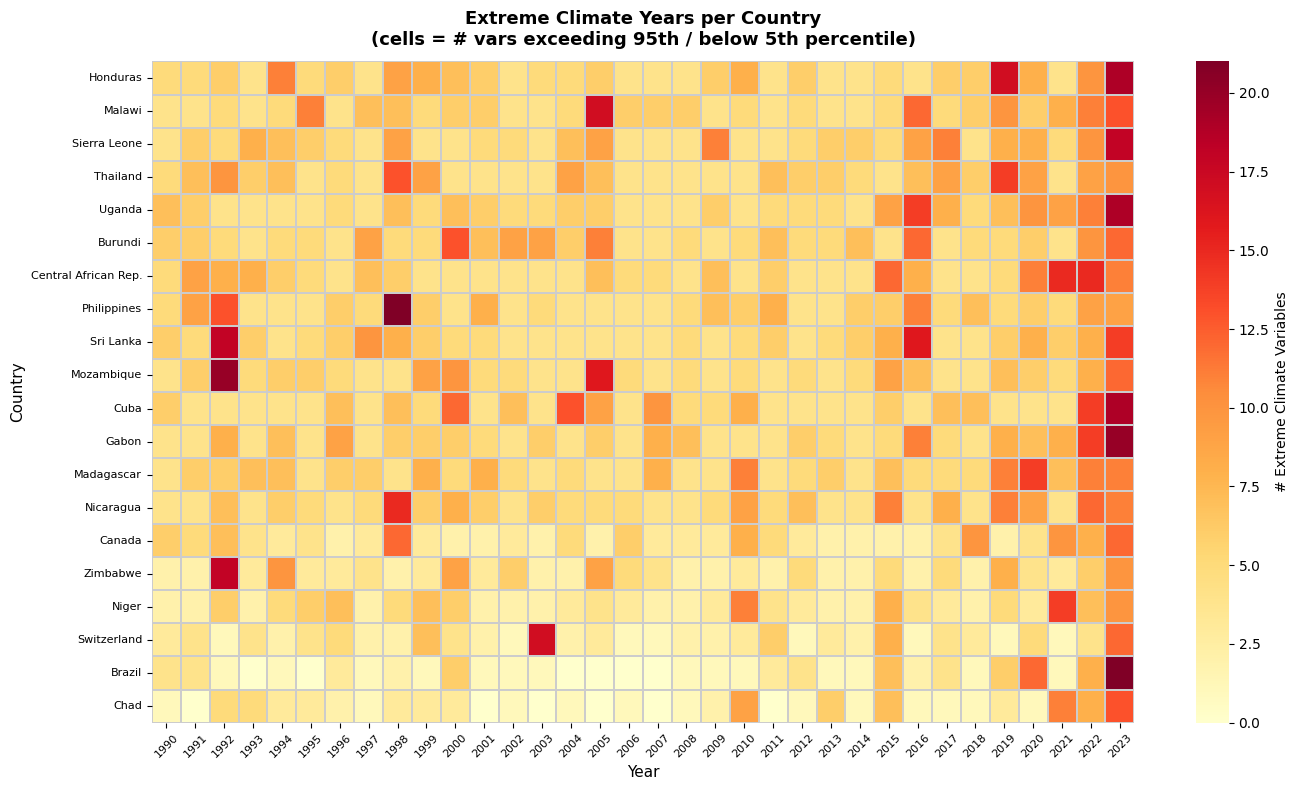

In [191]:
pivot = (extreme_df[extreme_df["is_extreme"]]
            .groupby(["country", "year"])["variable"]
            .count()
            .unstack(fill_value=0))


top_countries = pivot.sum(axis=1).nlargest(20).index
pivot = pivot.loc[top_countries]

fig, ax = plt.subplots(figsize=(max(14, len(pivot.columns) * 0.4),
                                    max(8, len(top_countries) * 0.3)))
cmap = plt.cm.YlOrRd
sns.heatmap(pivot, cmap=cmap, ax=ax, linewidths=0.3, linecolor= WHITE,
            cbar_kws={"label": "# Extreme Climate Variables"})
ax.set_title(f"Extreme Climate Years per Country\n"
                f"(cells = # vars exceeding {pct_high}th / below {pct_low}th percentile)",
                fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Country", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(extremes_plots_dir/"extremes_by_country.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

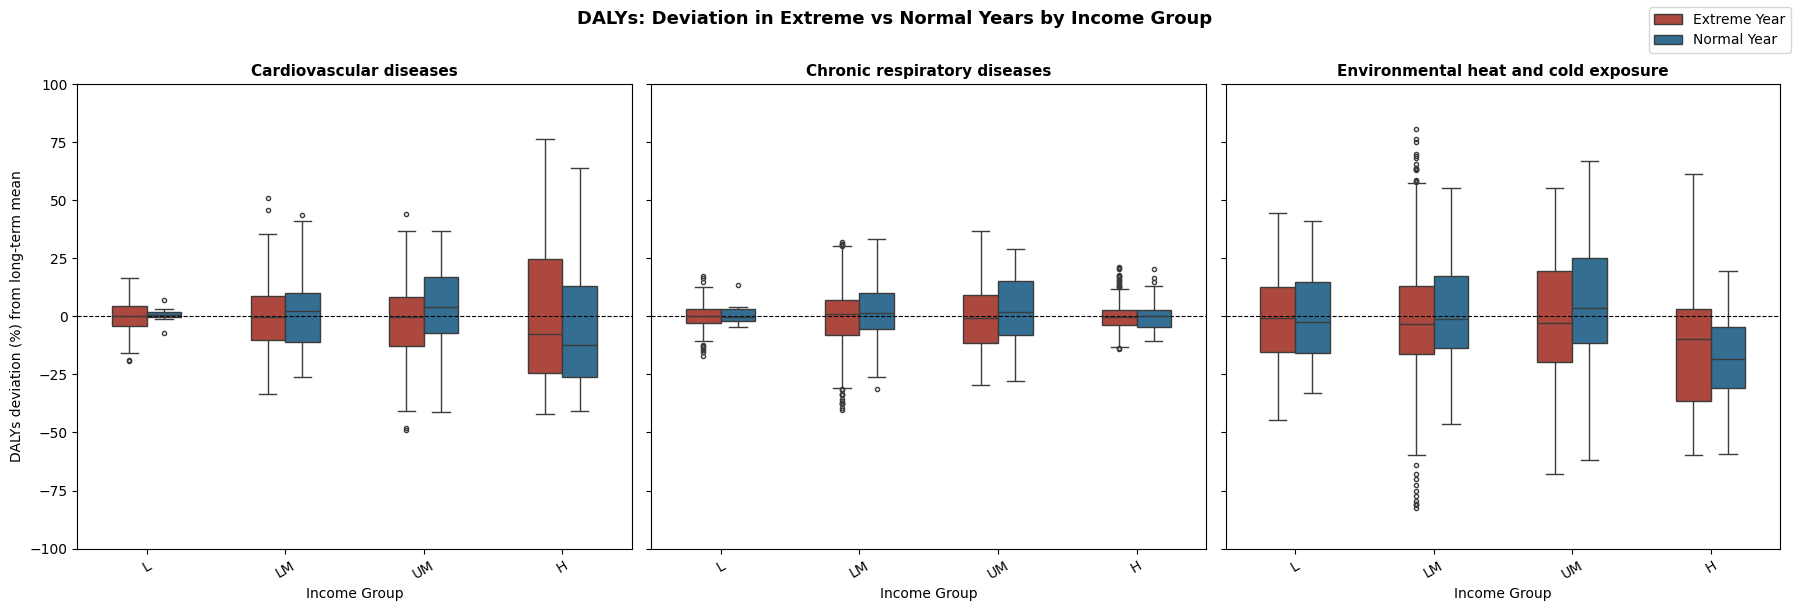

In [192]:
col = f"DALYs_dev_pct"
plot_df = health_dev_df.dropna(subset=[col]).copy()
plot_df["Year Type"] = plot_df["is_extreme_year"].map(
    {True: "Extreme Year", False: "Normal Year"})

causes = plot_df["cause"].unique()
n_causes = len(causes)
fig, axes = plt.subplots(1, n_causes,
                            figsize=(6 * n_causes, 6), sharey=True)
if n_causes == 1:
    axes = [axes]

palette = {"Normal Year": BLUE, "Extreme Year": RED}

for ax, cause in zip(axes, causes):
    subset = plot_df[plot_df["cause"] == cause]
    sns.boxplot(data=subset, x="income_level_mode", y=col,
                hue="Year Type", palette=palette,
                order=["L", "LM", "UM", "H"],
                ax=ax, width=0.5, fliersize=3)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylim(-100, 100)
    ax.set_title(cause, fontsize=11, fontweight="bold")
    ax.set_xlabel("Income Group")
    ax.set_ylabel(f"DALYs deviation (%) from long-term mean" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle(f"DALYs: Deviation in Extreme vs Normal Years by Income Group",
                fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(extremes_plots_dir/"DALYs_dev.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

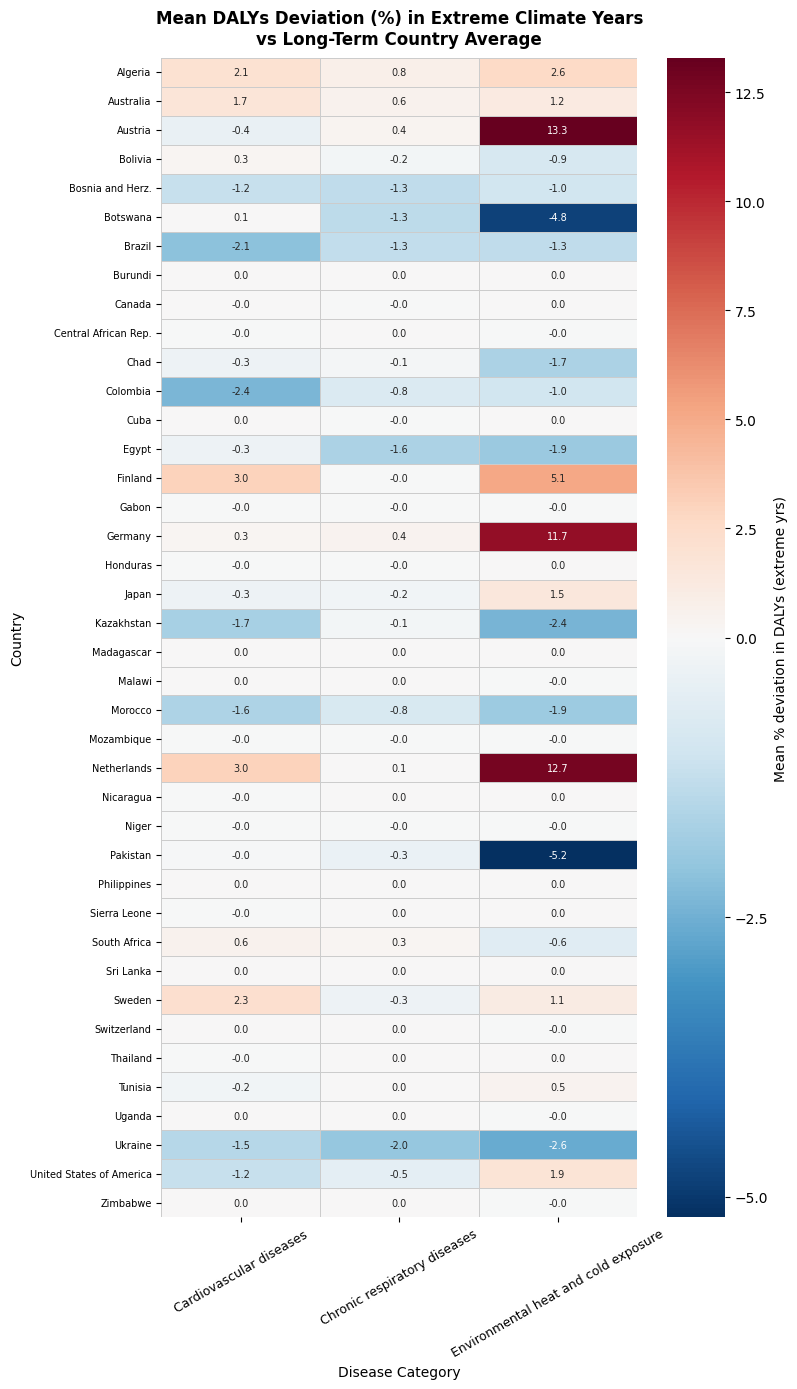

In [193]:
pivot = (health_dev_df[health_dev_df["is_extreme_year"]]
            .groupby(["country", "cause"])["DALYs_dev_pct"]
            .mean()
            .unstack())

fig, ax = plt.subplots(figsize=(max(8, pivot.shape[1] * 1.5),
                                    max(6, pivot.shape[0] * 0.35)))
divnorm = mcolors.TwoSlopeNorm(vmin=pivot.min().min(),
                                vcenter=0,
                                vmax=pivot.max().max())
sns.heatmap(pivot, cmap="RdBu_r", norm=divnorm, ax=ax,
            linewidths=0.4, linecolor=WHITE, annot=True,
            fmt=".1f", annot_kws={"size": 7},
            cbar_kws={"label": f"Mean % deviation in DALYs (extreme yrs)"})
ax.set_title(f"Mean DALYs Deviation (%) in Extreme Climate Years\nvs Long-Term Country Average",
                fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Disease Category")
ax.set_ylabel("Country")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.savefig(extremes_plots_dir/"DALYs_dev_1.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

However, these deviations may not be very representative and may be smoothed out, since we perceive an extreme year with any extreme variable (including one that may not correlate with the disease). So it should be checked later.

For now let's see how extreme heat may affect certain disease.

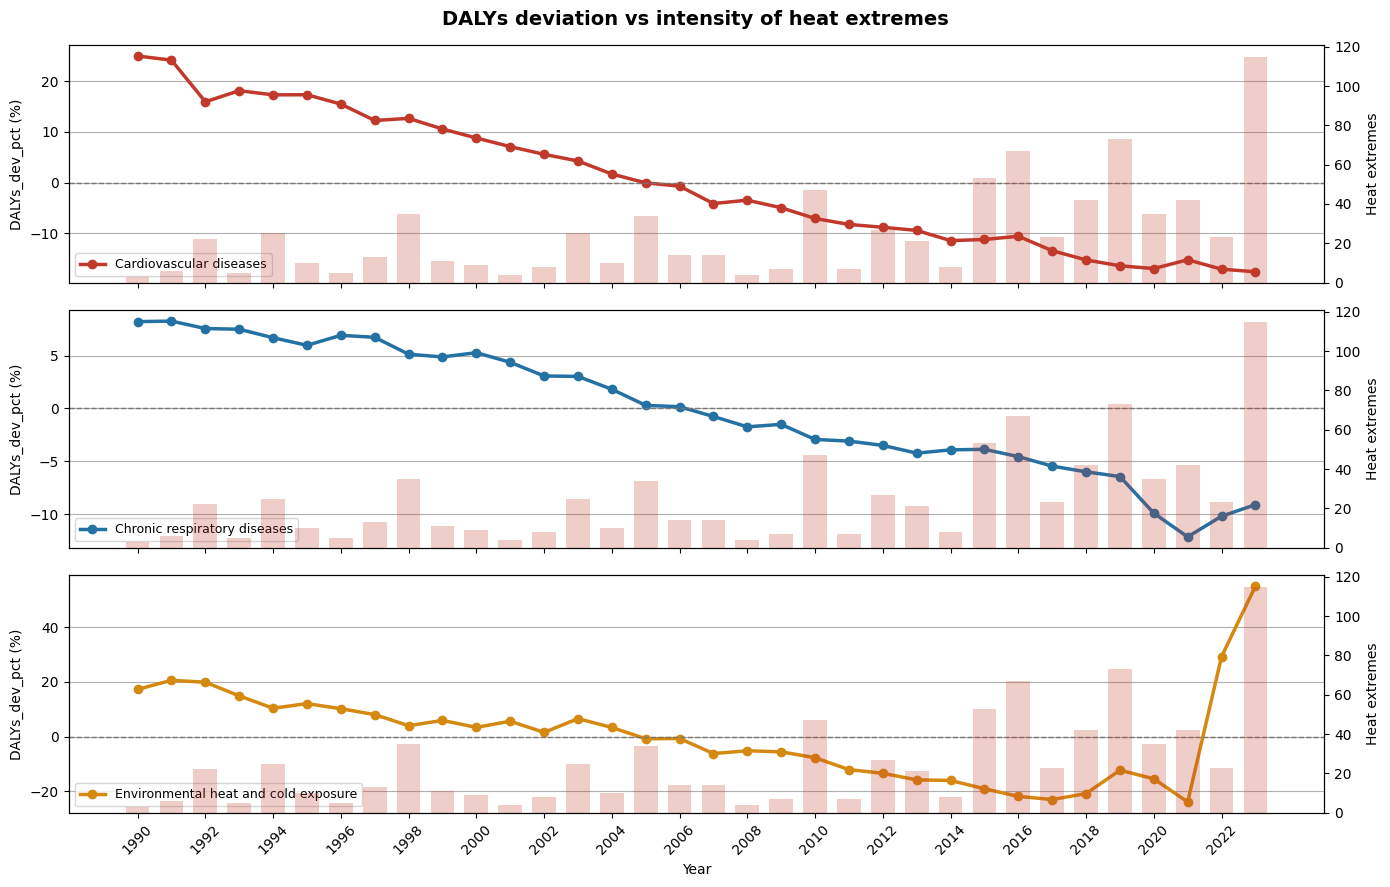

In [194]:
HEAT_VARS = {
    "mean_temp", "max_temp", "anomaly_heat_days", "heat_episodes", "extreme_heat_episodes",
    "extreme_area", "caution_area", "mean_caution_area", "mean_extreme_area"
}
health = final_table[final_table["is_extreme_year"] == True]

dalys_by_cause = (
    health.groupby(["year", "cause"])["DALYs_dev_pct"]
    .mean()
    .unstack()
)

heat_cnt_yr = (
    extreme_df[
        extreme_df["variable"].isin(HEAT_VARS) &
        (extreme_df["direction"] == "HIGH")
    ]
    .groupby("year")
    .size()
)

years_h = sorted(set(dalys_by_cause.index) & set(heat_cnt_yr.index))

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

fig.suptitle(
    "DALYs deviation vs intensity of heat extremes",
    fontsize=14,
    fontweight="bold"
)

colors_dalys = {
    "Cardiovascular diseases": RED,
    "Chronic respiratory diseases": BLUE,
    "Environmental heat and cold exposure": GOLD
}

for i, cause in enumerate(dalys_by_cause.columns):

    ax1 = axes[i]
    ax2 = ax1.twinx()

    dalys_series = dalys_by_cause[cause]
    ax2.bar(
        years_h,
        [heat_cnt_yr.get(y, 0) for y in years_h],
        color=RED,
        alpha=0.25,
        width=0.7,
        label="Heat extremes"
    )

    ax1.plot(
        years_h,
        [dalys_series.get(y, np.nan) for y in years_h],
        color=colors_dalys.get(cause,BLACK),
        lw=2.5,
        marker="o",
        label=cause
    )

    ax1.axhline(0, color=GRAY, ls="--", lw=1)

    ax1.set_ylabel("DALYs_dev_pct (%)")
    ax2.set_ylabel("Heat extremes")

    ax1.legend(loc="lower left", fontsize=9)
    ax1.yaxis.grid(True)
    ax1.set_axisbelow(True)

axes[-1].set_xlabel("Year")
axes[-1].set_xticks(years_h[::2])
axes[-1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.savefig(extremes_plots_dir/"DALYs_vs_heat.png", dpi=150, bbox_inches="tight")
plt.show()

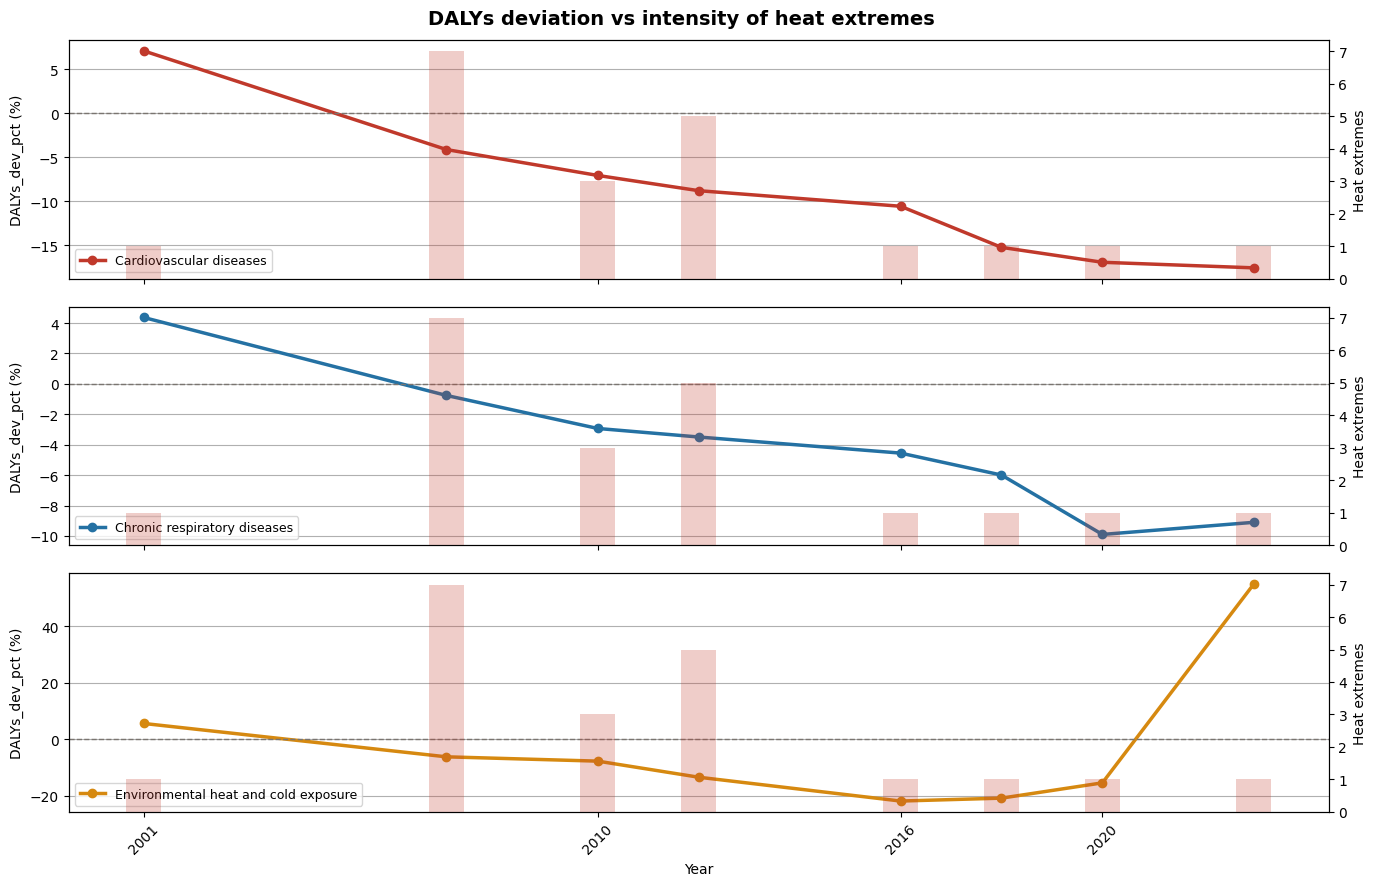

In [195]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

fig.suptitle(
    "DALYs deviation vs intensity of heat extremes",
    fontsize=14,
    fontweight="bold"
)
health_ukr = final_table[
    (final_table["is_extreme_year"] == True) & 
    (final_table["country"] == "Ukraine")
]
dalys_by_cause_ukr = (
    health.groupby(["year", "cause"])["DALYs_dev_pct"]
    .mean()
    .unstack()
)
heat_cnt_yr_ukr = (
    extreme_df[
        (extreme_df["country"] == "Ukraine") &
        extreme_df["variable"].isin(HEAT_VARS) &
        (extreme_df["direction"] == "HIGH")
    ]
    .groupby("year")
    .size()
)

years_h_ukr = sorted(set(dalys_by_cause_ukr.index) & set(heat_cnt_yr_ukr.index))
for i, cause in enumerate(dalys_by_cause_ukr.columns):

    ax1 = axes[i]
    ax2 = ax1.twinx()

    dalys_series = dalys_by_cause_ukr[cause]
    ax2.bar(
        years_h_ukr,
        [heat_cnt_yr_ukr.get(y, 0) for y in years_h_ukr],
        color=RED,
        alpha=0.25,
        width=0.7,
        label="Heat extremes"
    )

    ax1.plot(
        years_h_ukr,
        [dalys_series.get(y, np.nan) for y in years_h_ukr],
        color=colors_dalys.get(cause,BLACK),
        lw=2.5,
        marker="o",
        label=cause
    )

    ax1.axhline(0, color=GRAY, ls="--", lw=1)

    ax1.set_ylabel("DALYs_dev_pct (%)")
    ax2.set_ylabel("Heat extremes")

    ax1.legend(loc="lower left", fontsize=9)
    ax1.yaxis.grid(True)
    ax1.set_axisbelow(True)

axes[-1].set_xlabel("Year")
axes[-1].set_xticks(years_h_ukr[::2])
axes[-1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.savefig(extremes_plots_dir/"DALYs_vs_heat_ukr.png", dpi=150, bbox_inches="tight")
plt.show()

In [196]:
dalys_by_cause

cause,Cardiovascular diseases,Chronic respiratory diseases,Environmental heat and cold exposure
year,,,
1990,24.919923,8.218579,17.236467
1991,24.107792,8.268733,20.543309
1992,15.913927,7.566980,19.842035
1993,18.095880,7.495740,14.853224
1994,17.275445,6.695137,10.342525
1995,17.300817,5.977756,12.026510
1996,15.463225,6.922715,10.170674
1997,12.234752,6.731589,8.014226
1998,12.646797,5.136541,3.964176


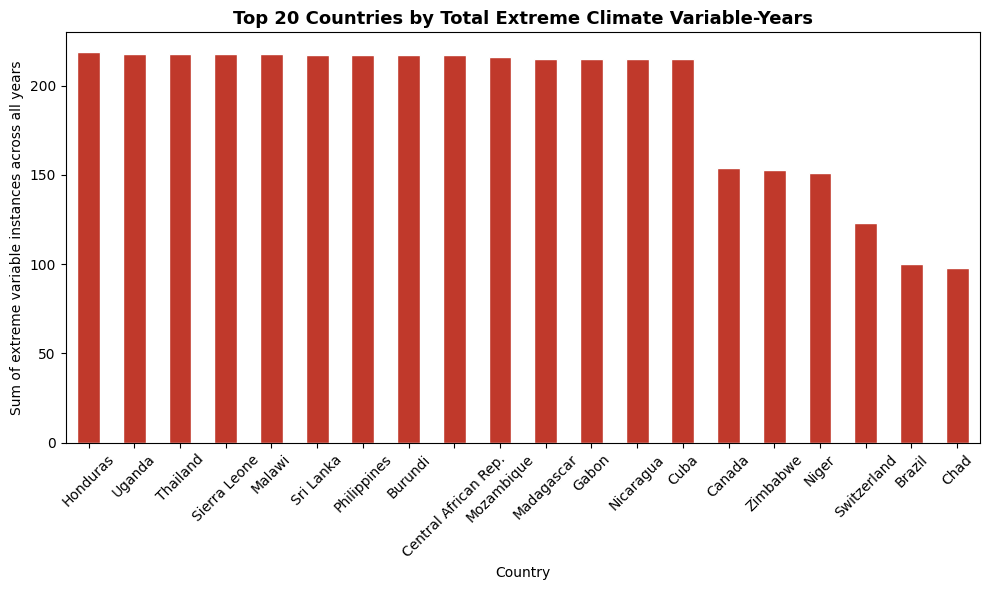

In [197]:
country_counts = (extreme_years_table
                    .groupby("country")["n_extreme_vars"]
                    .sum()
                    .sort_values(ascending=False)
                    .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
country_counts.plot(kind="bar", ax=ax, color=RED, edgecolor="white")
ax.set_title(f"Top {20} Countries by Total Extreme Climate Variable-Years",
                fontsize=13, fontweight="bold")
ax.set_xlabel("Country")
ax.set_ylabel("Sum of extreme variable instances across all years")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(extremes_plots_dir/"top_extreme_countries.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

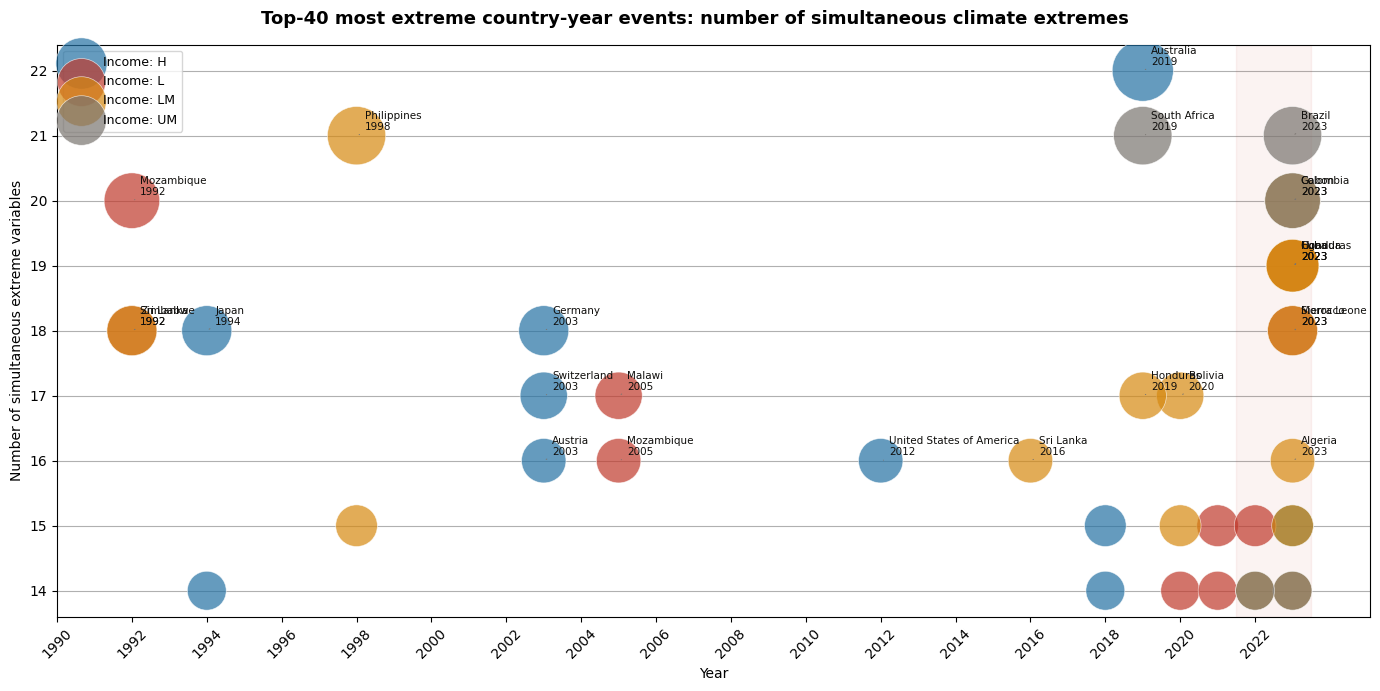

<Figure size 640x480 with 0 Axes>

In [198]:
top_cy = extreme_years_table.nlargest(40, "n_extreme_vars").copy()
income_map = (
    final_table[["country", "income_level_mode"]]
    .drop_duplicates()
    .set_index("country")["income_level_mode"]
    .to_dict()
)
top_cy["income"] = top_cy["country"].map(income_map)
income_colors = {
    "L": RED,
    "LM": GOLD,
    "UM": GRAY,
    "H": BLUE
}
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle(
    "Top-40 most extreme country-year events: number of simultaneous climate extremes",
    fontsize=13,
    fontweight="bold"
)
for inc, grp in top_cy.groupby("income"):
    ax.scatter(
        grp["year"],
        grp["n_extreme_vars"],
        s=grp["n_extreme_vars"]**2 * 4,
        color=income_colors.get(inc, GRAY),
        alpha=0.7,
        zorder=3,
        label=f"Income: {inc}",
        edgecolors="white",
        linewidths=0.5
    )

for _, row in top_cy.nlargest(25, "n_extreme_vars").iterrows():
    ax.annotate(
        f"{row['country']}\n{int(row['year'])}",
        xy=(row["year"], row["n_extreme_vars"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=7.5,
        color=BLACK,
        arrowprops=dict(arrowstyle="-", color=GRAY, lw=0.7)
    )

ax.set_xlabel("Year")
ax.set_ylabel("Number of simultaneous extreme variables")
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="upper left")
ax.axvspan(2021.5, extreme_years_table["year"].max() + 0.5, alpha=0.06, color=RED)
years_all = sorted(extreme_years_table["year"].unique())
ax.set_xticks(years_all[::2])
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()
plt.savefig(extremes_plots_dir/"top_extreme_countries_bubble.png", dpi=150, bbox_inches="tight")

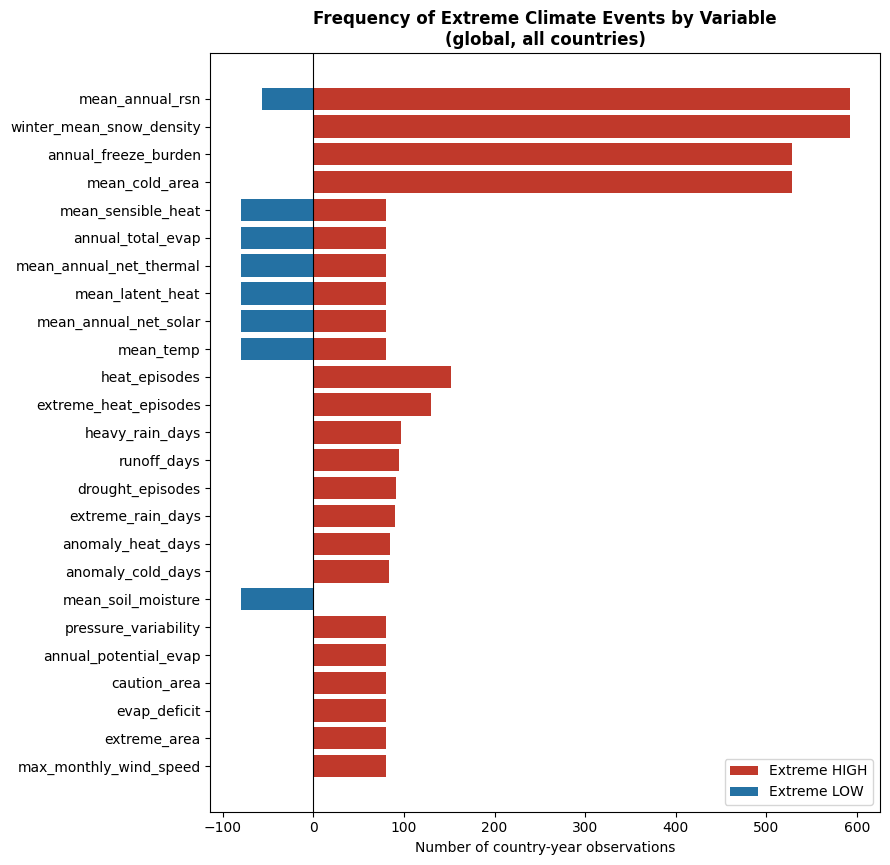

In [199]:
freq = (extreme_df[extreme_df["is_extreme"]]
        .groupby(["variable", "direction"])["country"]
        .count()
        .unstack(fill_value=0))

if "HIGH" not in freq.columns:
    freq["HIGH"] = 0
if "LOW" not in freq.columns:
    freq["LOW"] = 0

freq["total"] = freq["HIGH"] + freq["LOW"]
freq = freq.sort_values("total", ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(9, max(7, len(freq) * 0.35)))
ax.barh(freq.index, freq.get("HIGH", 0), color=RED, label="Extreme HIGH")
ax.barh(freq.index, -freq.get("LOW", 0),  color=BLUE, label="Extreme LOW")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Number of country-year observations")
ax.set_title("Frequency of Extreme Climate Events by Variable\n(global, all countries)",
                fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(extremes_plots_dir/"extreme_climate_variable_freq.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

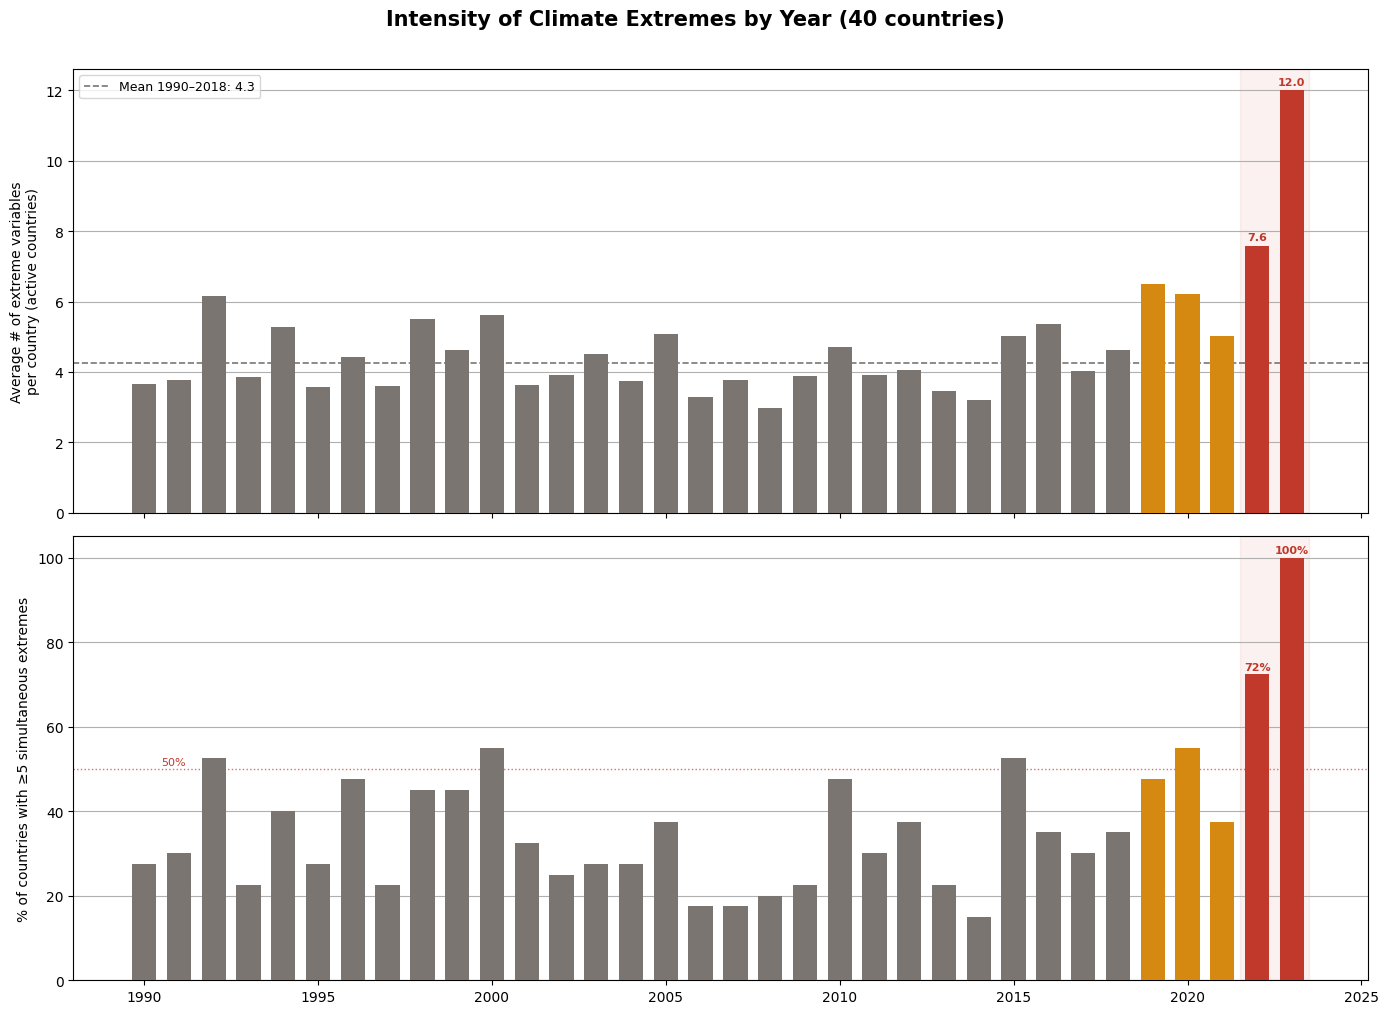

In [200]:
n_countries = extreme_years_table["country"].nunique()

by_year = extreme_years_table.groupby("year")["n_extreme_vars"].agg(["mean", "median", "max"]).reset_index()
countries_ge5 = extreme_years_table[extreme_years_table["n_extreme_vars"] >= 5] \
    .groupby("year").size().reset_index(name="cnt")
countries_ge5["pct"] = countries_ge5["cnt"] / n_countries * 100

countries_any = extreme_years_table.groupby("year")["country"].nunique().reset_index(name="n_any")

years_all = sorted(extreme_years_table["year"].unique())
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Intensity of Climate Extremes by Year (40 countries)", fontsize=15, fontweight="bold", y=1.01)

ax1, ax2 = axes

# Panel 1: mean number of extreme variables
colors_bar = [RED if y >= 2022 else GOLD if y >= 2019 else GRAY for y in by_year["year"]]
ax1.bar(by_year["year"], by_year["mean"], color=colors_bar, width=0.7, zorder=3)
ax1.axhline(by_year[by_year["year"] <= 2018]["mean"].mean(), color=GRAY, ls="--", lw=1.2,
            label=f"Mean 1990–2018: {by_year[by_year['year'] <= 2018]['mean'].mean():.1f}")
ax1.set_ylabel("Average # of extreme variables\nper country (active countries)")
ax1.legend(fontsize=9)
ax1.yaxis.grid(True, zorder=0)
ax1.set_axisbelow(True)
for y, v in zip(by_year["year"], by_year["mean"]):
    if y >= 2022:
        ax1.text(y, v + 0.1, f"{v:.1f}", ha="center", va="bottom", fontsize=8, color=RED, fontweight="bold")

# Panel 2: % of countries with ≥5 extremes
merged_pct = pd.DataFrame({"year": years_all}).merge(countries_ge5, on="year", how="left").fillna(0)
ax2.bar(merged_pct["year"], merged_pct["pct"], color=colors_bar, width=0.7, zorder=3)
ax2.set_ylabel("% of countries with ≥5 simultaneous extremes")
ax2.yaxis.grid(True, zorder=0)
ax2.set_axisbelow(True)
ax2.axhline(50, color=RED, ls=":", lw=1, alpha=0.7)
ax2.text(1990.5, 51, "50%", color=RED, fontsize=8)
for y, v in zip(merged_pct["year"], merged_pct["pct"]):
    if y >= 2022 and v > 0:
        ax2.text(y, v + 0.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=8, color=RED, fontweight="bold")
for ax in axes:
    ax.axvspan(2021.5, max(years_all) + 0.5, alpha=0.07, color=RED, zorder=0)

fig.tight_layout()
plt.savefig(extremes_plots_dir/"extreme_climate_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

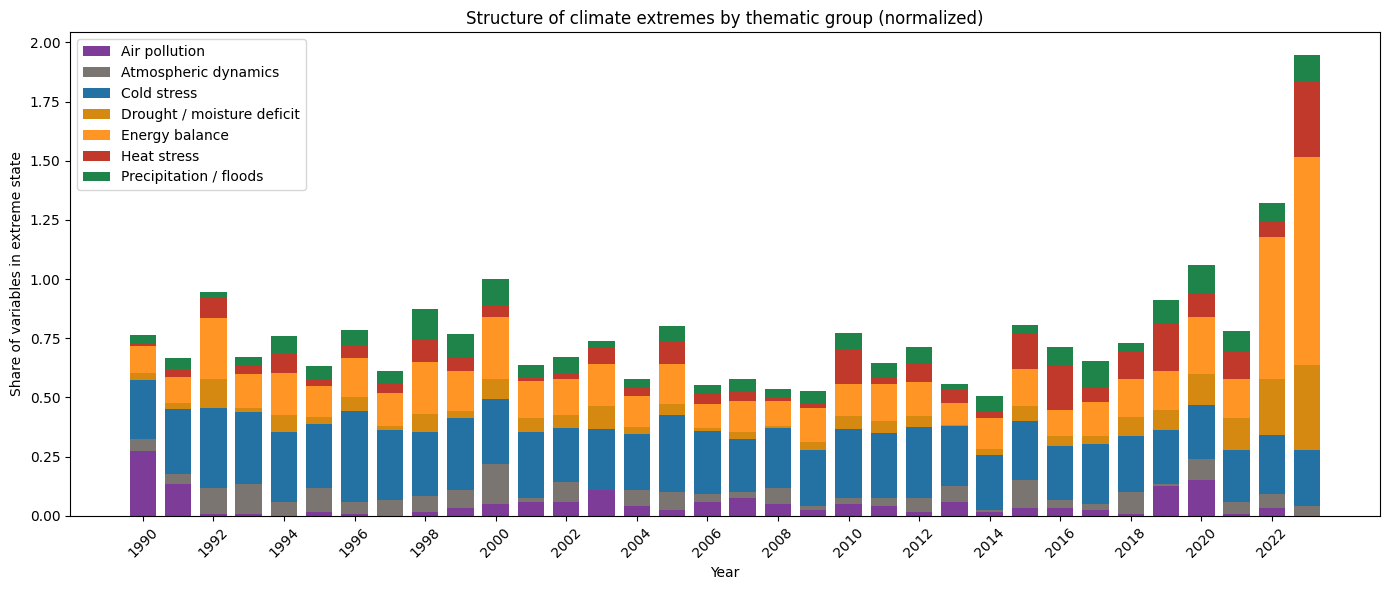

In [201]:
# Heat stress
HEAT_VARS = {
    "mean_temp", "max_temp", "anomaly_heat_days", "heat_episodes", "extreme_heat_episodes",
    "extreme_area", "caution_area", "mean_caution_area", "mean_extreme_area"
}
# Cold stress
COLD_VARS = {
    "anomaly_cold_days", "annual_freeze_burden", "min_temp", "winter_mean_snow_density", "mean_cold_area"
}
# Precipitation / runoff / floods
PRECIP_VARS = {
    "heavy_rain_days", "extreme_rain_days", "max_year_precip", "runoff_days", "max_runoff"
}
# Drought / moisture deficit
DROUGHT_VARS = {
    "annual_dry_area", "drought_episodes", "mean_dry_area", "evap_deficit", "mean_soil_moisture",
    "min_monthly_soil_moisture", "annual_potential_evap", "annual_total_evap"
}
# Air pollution
AIR_VARS = {
    "pm2.5_mean", "ozone_mean", "no2_mean"
}
# Atmospheric dynamics (wind + pressure)
ATMOS_VARS = {
    "max_monthly_wind_speed", "mean_annual_wind_speed", "pressure_variability"
}
# Energy balance / radiation / heat fluxes
ENERGY_VARS = {
    "mean_annual_net_solar", "mean_annual_net_thermal", "mean_latent_heat",
    "mean_sensible_heat", "mean_annual_rsn"
}

GROUPS = {
    "Heat stress": HEAT_VARS, "Cold stress": COLD_VARS, "Precipitation / floods": PRECIP_VARS,
    "Drought / moisture deficit": DROUGHT_VARS, "Air pollution": AIR_VARS,
    "Atmospheric dynamics": ATMOS_VARS, "Energy balance": ENERGY_VARS
}
years_all = sorted(extreme_df["year"].unique())
records = []

for name, vars_set in GROUPS.items():
    sub = extreme_df[extreme_df["variable"].isin(vars_set)]
    sub = sub[sub["is_extreme"]]
    counts = sub.groupby("year").size()
    n_vars = len(vars_set)
    for y in years_all:
        extreme_obs = counts.get(y, 0)
        rate = extreme_obs / (n_countries * n_vars)
        records.append({
            "year": y,
            "group": name,
            "rate": rate
        })

group_year = pd.DataFrame(records)
pivot = group_year.pivot(index="year", columns="group", values="rate").fillna(0)

fig, ax = plt.subplots(figsize=(14,6))
bottom = np.zeros(len(pivot))
colors = {
    "Heat stress": RED,
    "Cold stress": BLUE,
    "Drought / moisture deficit": GOLD,
    "Air pollution": PURPLE,
    "Precipitation / floods": GREEN,
    "Atmospheric dynamics": GRAY,
    "Energy balance": ORANGE
}

for g in pivot.columns:
    ax.bar(
        pivot.index,
        pivot[g],
        bottom=bottom,
        label=g,
        color=colors[g],
        width=0.75
    )
    bottom += pivot[g].values

ax.set_ylabel("Share of variables in extreme state")
ax.set_xlabel("Year")
ax.set_title("Structure of climate extremes by thematic group (normalized)")
ax.legend(loc="upper left")
ax.set_xticks(years_all[::2])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(extremes_plots_dir/"extremes_structure.png", dpi=150, bbox_inches="tight")
plt.show()

# Maps

In [202]:
maps_dir = Path("../results/trend_plots/maps")

In [203]:
ISO_LOOKUP = {
    "Ukraine": "UKR",
    "Bosnia and Herz.": "BIH", 
    "Germany": "DEU",
    "Austria": "AUT",
    "Switzerland": "CHE",
    "Netherlands": "NLD",
    "Denmark": "DNK",
    "Sweden": "SWE",
    "Finland": "FIN",
    "Pakistan": "PAK",
    "Sri Lanka": "LKA",
    "Thailand": "THA",
    "Philippines": "PHL",
    "Japan": "JPN",
    "Canada": "CAN",
    "Australia": "AUS",
    "Brazil": "BRA",
    "Bolivia": "BOL",
    "Colombia": "COL",
    "Cuba": "CUB",
    "Honduras": "HND",
    "Nicaragua": "NIC",
    "Zimbabwe": "ZWE",
    "Malawi": "MWI",
    "Niger": "NER",
    "Burundi": "BDI",
    "Chad": "TCD",
    "Central African Rep.": "CAF",
    "Mozambique": "MOZ",
    "Sierra Leone": "SLE",
    "Madagascar": "MDG",
    "Uganda": "UGA",
    "Gabon": "GAB",
    "South Africa": "ZAF",
    "Botswana": "BWA",
    "Algeria": "DZA",
    "Morocco": "MAR",
    "Tunisia": "TUN",
    "Egypt": "EGY",
    "United States of America": "USA",
    "Kazakhstan": "KAZ",
}
health_df["iso3"] = health_df["country"].map(ISO_LOOKUP)

In [204]:
SNAPSHOT_YEARS = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2023]
CAUSES = health_df["cause"].unique().tolist()

for cause in CAUSES:
    df_cause = health_df[health_df["cause"] == cause]
    snap = df_cause[df_cause["year"].isin(SNAPSHOT_YEARS)].copy()

    fig = px.choropleth(
        snap,
        locations="iso3",
        color="DALYs",
        hover_name="country",
        hover_data={"DALYs": ":.1f", "income_level_mode": True},
        animation_frame="year",
        color_continuous_scale="YlOrRd",
        range_color=(snap["DALYs"].quantile(0.05), snap["DALYs"].quantile(0.95)),
        title=f"DALYs Rate — {cause} (1990 / 1995 / 2000 / 2005 / 2010 / 2015 / 2020 / 2023)",
        labels={"DALYs": "DALYs rate"}
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
        coloraxis_colorbar=dict(title="DALYs rate"),
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.show()
    output_name = cause.replace(" ", "_").replace("/", "_")
    png_path = maps_dir / f"{output_name}_dalys_trend.png"
    html_path = maps_dir / f"{output_name}_dalys_trend.html"
    
    fig.write_image(str(png_path), scale=3, width=1200, height=800)
    fig.write_html(str(html_path))
    print(f"Saved {cause}: {png_path} (PNG) & {html_path} (interactive HTML)")


Saved Cardiovascular diseases: ..\results\trend_plots\maps\Cardiovascular_diseases_dalys_trend.png (PNG) & ..\results\trend_plots\maps\Cardiovascular_diseases_dalys_trend.html (interactive HTML)


Saved Chronic respiratory diseases: ..\results\trend_plots\maps\Chronic_respiratory_diseases_dalys_trend.png (PNG) & ..\results\trend_plots\maps\Chronic_respiratory_diseases_dalys_trend.html (interactive HTML)


Saved Environmental heat and cold exposure: ..\results\trend_plots\maps\Environmental_heat_and_cold_exposure_dalys_trend.png (PNG) & ..\results\trend_plots\maps\Environmental_heat_and_cold_exposure_dalys_trend.html (interactive HTML)


## Slopes

In [205]:
country_trend_df["iso3"] = country_trend_df["country"].map(ISO_LOOKUP)
country_trend_df["significant"] = country_trend_df["p_value"] < 0.05
country_trend_df["trend_type"] = np.where(
    country_trend_df["p_value"] >= 0.05, "Not significant",
    np.where(country_trend_df["slope"] > 0, "Increasing", "Decreasing")
)

CAUSES = country_trend_df["cause"].unique()

for cause in CAUSES:
    df_c = country_trend_df[country_trend_df["cause"] == cause].copy()
    abs_max = df_c["slope"].abs().quantile(0.95)

    fig = px.choropleth(
        df_c,
        locations="iso3",
        color="slope",
        hover_name="country",
        hover_data={"slope": ":.2f", "p_value": ":.3f", "significant": True},
        color_continuous_scale="RdBu_r",
        range_color=(-abs_max, abs_max),
        title=f"Trend in DALYs (slope, DALYs/year) — {cause}",
        labels={"slope": "DALYs/year"}
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
        coloraxis_colorbar=dict(title="DALYs/year"),
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.show()
    output_name = cause.replace(" ", "_").replace("/", "_")
    png_path = maps_dir / f"{output_name}_slope_trend.png"
    html_path = maps_dir / f"{output_name}_slope_trend.html"
    
    fig.write_image(str(png_path), scale=3, width=1200, height=800)
    fig.write_html(str(html_path))
    
    print(f"{cause}: {png_path}")


Cardiovascular diseases: ..\results\trend_plots\maps\Cardiovascular_diseases_slope_trend.png


Chronic respiratory diseases: ..\results\trend_plots\maps\Chronic_respiratory_diseases_slope_trend.png


Environmental heat and cold exposure: ..\results\trend_plots\maps\Environmental_heat_and_cold_exposure_slope_trend.png


In [206]:
COLOUR_MAP = {
    "Increasing":      RED,
    "Decreasing":      BLUE,
    "Not significant": GRAY
}

for cause in CAUSES:
    df_c = country_trend_df[country_trend_df["cause"] == cause].copy()
    fig = px.choropleth(
        df_c,
        locations="iso3",
        color="trend_type",
        hover_name="country",
        hover_data={"slope": ":.2f", "p_value": ":.3f"},
        color_discrete_map=COLOUR_MAP,
        category_orders={"trend_type": ["Increasing", "Decreasing", "Not significant"]},
        title=f"Trend Direction (significant at p<0.05) — {cause}",
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
        legend=dict(title="Trend", orientation="h", y=-0.05),
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.show()
    output_name = cause.replace(" ", "_").replace("/", "_")
    png_path = maps_dir / f"{output_name}_dalys_trend_dir.png"
    html_path = maps_dir / f"{output_name}_dalys_trend_dir.html"
    
    fig.write_image(str(png_path), scale=3, width=1200, height=800)
    fig.write_html(str(html_path))

In [207]:
slope_income = country_trend_df.merge(
    health_df[["country", "income_level_mode"]].drop_duplicates(),
    on="country"
)

INCOME_ORDER = ["Low income", "Lower middle income", "Upper middle income", "High income"]

for cause in CAUSES:
    df_c = slope_income[slope_income["cause"] == cause].copy()

    df_c["label"] = df_c["income_level_mode"] + " / " + df_c["trend_type"]

    fig = px.choropleth(
        df_c,
        locations="iso3",
        color="income_level_mode",
        hover_name="country",
        hover_data={"trend_type": True, "slope": ":.2f", "income_level_mode": True},
        color_discrete_sequence=px.colors.qualitative.Set2,
        category_orders={"income_level_mode": INCOME_ORDER},
        title=f"Income Group (hover for trend direction) — {cause}",
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
        legend=dict(title="Income group", orientation="h", y=-0.05),
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.show()
    output_name = cause.replace(" ", "_").replace("/", "_")
    png_path = maps_dir / f"{output_name}_dalys_trend_income.png"
    html_path = maps_dir / f"{output_name}_dalys_trend_income.html"
    
    fig.write_image(str(png_path), scale=3, width=1200, height=800)
    fig.write_html(str(html_path))


## Hotspots

In [208]:
pct_rows = []

for cause in health_df["cause"].unique():
    df_c = health_df[health_df["cause"] == cause]
    for country in df_c["country"].unique():
        sub = df_c[df_c["country"] == country].groupby("year")["DALYs"].mean()
        if len(sub) < 5:
            continue
        # Geometric Mean Annual Change
        non_zero = sub[sub > 0]
        if len(non_zero) < 3:
            continue
            
        annual_changes = non_zero.pct_change().dropna()
        gmac = (1 + annual_changes.mean()) ** 1 * 100 - 100
        
        pct_rows.append({
            "country": country,
            "cause": cause,
            "gmac": gmac,
            "years_n": len(sub),
            "DALYs_1990": sub.get(1990, np.nan),
            "DALYs_2023": sub.get(2023, np.nan)
        })

pct_df = pd.DataFrame(pct_rows)
pct_df["iso3"] = pct_df["country"].map(ISO_LOOKUP)

pct_df["spot_type"] = pd.cut(
    pct_df["gmac"],
    bins=[-np.inf, -5, -2, 2, 5, np.inf],
    labels=["Coldspot (<-5%/yr)", "Mild decline", "Stable", "Mild increase", "Hotspot (>5%/yr)"]
)
pct_df

,country,cause,gmac,years_n,DALYs_1990,DALYs_2023,iso3,spot_type
0,Algeria,Cardiovascular diseases,-1.491821,34,11253.922792,6843.118427,DZA,Stable
1,Bolivia,Cardiovascular diseases,-1.255351,34,6382.101813,4080.860320,BOL,Stable
2,Burundi,Cardiovascular diseases,0.244856,34,5695.540335,6119.480562,BDI,Stable
3,Central African Rep.,Cardiovascular diseases,-0.065132,34,7492.953127,7257.321667,CAF,Stable
4,Chad,Cardiovascular diseases,-0.117490,34,9260.339735,8802.925431,TCD,Stable
...,...,...,...,...,...,...,...,...
115,Thailand,Environmental heat and cold exposure,0.503521,34,4.721084,4.014527,THA,Stable
116,Netherlands,Environmental heat and cold exposure,27.949345,34,7.681675,67.494217,NLD,Hotspot (>5%/yr)
117,Sweden,Environmental heat and cold exposure,1.387111,34,18.144343,17.191637,SWE,Stable
118,Switzerland,Environmental heat and cold exposure,44.158226,34,7.531145,88.977032,CHE,Hotspot (>5%/yr)


In [209]:
for cause in pct_df["cause"].unique():
    df_c = pct_df[pct_df["cause"] == cause]
    
    fig = px.choropleth(
        df_c, locations="iso3", color="gmac",
        hover_name="country",
        hover_data={"gmac": ":.1f%", "years_n": True},
        color_continuous_scale="RdBu_r",
        title=f"Hotspot Analysis (GMAC %/year) — {cause}",
        labels={"gmac": "Annual % change"}
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
        coloraxis_colorbar=dict(
            title="% change",
            tickvals=[-abs_max, -30, 0, 30, abs_max],
            ticktext=[f"−{abs_max:.0f}%", "−30%", "0%", "+30%", f"+{abs_max:.0f}%"]
        ),
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.show()

    output_name = cause.replace(" ", "_")
    png_path = maps_dir / f"{output_name}_hotspot.png"
    html_path = maps_dir / f"{output_name}_hotspot.html"
    
    fig.write_image(str(png_path), scale=3, width=1200, height=800)
    fig.write_html(str(html_path))    
